# **Raquel Rocha**
### **Projeto Integrador — Análise Exploratória e Machine Learning: Gastos Parlamentares**

---

# **0.0 Imports**

In [1]:
import warnings
import numpy               as np
import pandas              as pd
import seaborn             as sns
import plotly.express      as px
import matplotlib.gridspec as gridspec

from scipy.stats           import shapiro, chi2_contingency, zscore
from sklearn.ensemble      import IsolationForest
from sklearn.preprocessing import RobustScaler, LabelEncoder
from IPython.core.display  import HTML
from matplotlib            import pyplot as plt

warnings.filterwarnings('ignore')

## **0.1 Helper Functions**

In [2]:
def jupyter_settings():
    %matplotlib inline

    plt.style.use('bmh')
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 24

    display(HTML('<style>.container { width:100% !important; }</style>'))
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option('display.expand_frame_repr', False)

    sns.set()

jupyter_settings()
warnings.filterwarnings('ignore')


def descriptive_statistics(df_num):
    ct1 = pd.DataFrame(df_num.apply(np.mean)).T
    ct2 = pd.DataFrame(df_num.apply(np.median)).T
    ct3 = pd.DataFrame(df_num.apply(np.std)).T
    ct4 = pd.DataFrame(df_num.apply(min)).T
    ct5 = pd.DataFrame(df_num.apply(max)).T
    ct6 = pd.DataFrame(df_num.apply(lambda x: x.max() - x.min())).T
    ct7 = pd.DataFrame(df_num.apply(lambda x: x.skew())).T
    ct8 = pd.DataFrame(df_num.apply(lambda x: x.kurtosis())).T
    ct9 = pd.DataFrame(df_num.apply(
        lambda x: 'not normal' if shapiro(x.dropna().sample(min(5000, len(x.dropna())), random_state=42))[1] < 0.05 else 'normal'
    )).T

    df_stats = pd.concat([ct4, ct5, ct6, ct1, ct2, ct3, ct7, ct8, ct9]).T
    df_stats.columns = ['min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis', 'shapiro']

    return df_stats.round(2)


def cramer_v(x, y):
    cm = pd.crosstab(x, y).values
    n  = cm.sum()
    r, k = cm.shape

    chi2 = chi2_contingency(cm)[0]

    chi2corr = max(0, chi2 - (k-1)*(r-1)/(n-1))
    kcorr    = k - (k-1)**2/(n-1)
    rcorr    = r - (r-1)**2/(n-1)

    return np.sqrt((chi2corr/n) / (min(kcorr-1, rcorr-1)))

## **0.2 Loading Data**

Essa etapa visa entender como será feito o loading dos dados necessários para elaborar as análises:

• load dos csvs

• entender a granularidade dos dados

• perceber as chaves primárias e estrangeiras para efetivar os joins

• verificar se o arquivo final (raw) manteve o número correto de linhas

In [3]:
df_raw_despesas      = pd.read_csv('despesas.csv', low_memory=False)
df_raw_deputados     = pd.read_csv('deputados.csv', low_memory=False)
df_raw_tipos_despesa = pd.read_csv('tipos_despesa.csv', low_memory=False)

In [4]:
print('Number of Rows despesas     : {}'.format(df_raw_despesas.shape[0]))
print('Number of Rows deputados    : {}'.format(df_raw_deputados.shape[0]))
print('Number of Rows tipos_despesa: {}'.format(df_raw_tipos_despesa.shape[0]))

Number of Rows despesas     : 668911
Number of Rows deputados    : 641
Number of Rows tipos_despesa: 23


In [5]:
#verificando os nomes das colunas
df_raw_despesas.sample(3)

,id_deputado,ano,mes,tipo_despesa,cod_documento,data_documento,valor_documento,valor_liquido,valor_glosa,nome_fornecedor,cnpj_cpf_fornecedor,num_documento,url_documento
59093,220549,2025,7,COMBUSTÍVEIS E LUBRIFICANTES.,7954055,2025-07-25 15:58:14,228.25,228.25,0.0,MP POSTOS E LOGISTICA LTDA BOA VISTA DO BURICA...,2.344896e+13,558822,http://www.camara.leg.br/cota-parlamentar/nota...
605989,220621,2025,2,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7864573,2025-02-05 00:00:00,741.70,741.70,0.0,WMS COMERCIO DE ARTIGOS DE PAPELARIA LTDA,1.213285e+13,6290,http://www.camara.leg.br/cota-parlamentar/nota...
155668,204367,2026,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,8041395,2026-01-01 00:00:00,580.00,580.00,0.0,FLN LOCAÇÃO E COMERCIALIZAÇÃO DE MÁQUINAS E CAFÉ,5.771865e+13,176,https://www.camara.leg.br/cota-parlamentar/doc...


In [6]:
#merge para trazer partido e uf nas despesas
df_raw = df_raw_despesas.merge(df_raw_deputados[['id_deputado', 'nome', 'partido', 'uf']],
                               on='id_deputado', how='left')

print('Number of Rows após join: {}'.format(df_raw.shape[0]))

Number of Rows após join: 668911


---
# **1.0 Data Description**

In [7]:
df1 = df_raw.copy()

In [8]:
df1.columns

Index(['id_deputado', 'ano', 'mes', 'tipo_despesa', 'cod_documento',
       'data_documento', 'valor_documento', 'valor_liquido', 'valor_glosa',
       'nome_fornecedor', 'cnpj_cpf_fornecedor', 'num_documento',
       'url_documento', 'nome', 'partido', 'uf'],
      dtype='object')

## **1.1 Data Dimensions**

In [9]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Cols: {}'.format(df1.shape[1]))

Number of Rows: 668911
Number of Cols: 16


## **1.2 Data Types**

Nesse passo verifico se o tipo dos dados confere com o esperado.
Identificamos variáveis com tipo a ser modificado:

• `id_deputado`: int64 → deve ser texto (identificador)

• `cnpj_cpf_fornecedor`: float64 → deve ser texto (preserva zeros e formatação)

• `data_documento`: object → deve ser datetime

In [10]:
df1.dtypes

,0
id_deputado,int64
ano,int64
mes,int64
tipo_despesa,object
cod_documento,object
data_documento,object
valor_documento,float64
valor_liquido,float64
valor_glosa,float64
nome_fornecedor,object


In [11]:
df1.head(3)

,id_deputado,ano,mes,tipo_despesa,cod_documento,data_documento,valor_documento,valor_liquido,valor_glosa,nome_fornecedor,cnpj_cpf_fornecedor,num_documento,url_documento,nome,partido,uf
0,220593,2023,9,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7610066,2023-09-19 00:00:00,52.98,52.98,0.0,3XIS COMERCIO VAREJISTA E ATACADISTA DE PAPELA...,4.299980e+13,35537,http://www.camara.leg.br/cota-parlamentar/nota...,Abilio Brunini,PL,MT
1,220593,2023,11,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7657491,2023-11-27 00:00:00,67.30,67.30,0.0,AGUAS CUIABA S.A,1.499558e+13,01,https://www.camara.leg.br/cota-parlamentar/doc...,Abilio Brunini,PL,MT
2,220593,2023,5,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7552621,2023-05-05 00:00:00,43.20,43.20,0.0,AGUAS CUIABA S.A,1.499558e+13,11533052023001,https://www.camara.leg.br/cota-parlamentar/doc...,Abilio Brunini,PL,MT


## **1.3 Check NA**

In [12]:
df1.isna().sum()

,0
id_deputado,0
ano,0
mes,0
tipo_despesa,0
cod_documento,0
data_documento,0
valor_documento,0
valor_liquido,0
valor_glosa,0
nome_fornecedor,0


In [13]:
(df1.isna().sum() / len(df1) * 100).round(2)

,0
id_deputado,0.00
ano,0.00
mes,0.00
tipo_despesa,0.00
cod_documento,0.00
data_documento,0.00
valor_documento,0.00
valor_liquido,0.00
valor_glosa,0.00
nome_fornecedor,0.00


## **1.4 Fillout NA**

Verificando a quantidade de dados nulos:

• `cnpj_cpf_fornecedor`: 20% de nulos — esperado para despesas via SIGEPA, que não exige CNPJ.

• `url_documento`: 23% de nulos — nem todo documento possui URL disponível.

• `num_documento`: nulos residuais (<1%).

Decisão: preencher com 'NAO INFORMADO' para manter a integridade da base.

In [14]:
df1['cnpj_cpf_fornecedor'] = df1['cnpj_cpf_fornecedor'].fillna('NAO INFORMADO')
df1['url_documento']       = df1['url_documento'].fillna('NAO INFORMADO')
df1['num_documento']       = df1['num_documento'].fillna('NAO INFORMADO')
df1['nome_fornecedor']     = df1['nome_fornecedor'].fillna('NAO INFORMADO')
df1['partido']             = df1['partido'].fillna('SEM PARTIDO')
df1['uf']                  = df1['uf'].fillna('NAO INFORMADO')

In [15]:
df1.isna().sum()

,0
id_deputado,0
ano,0
mes,0
tipo_despesa,0
cod_documento,0
data_documento,0
valor_documento,0
valor_liquido,0
valor_glosa,0
nome_fornecedor,0


## **1.5 Change Types**

In [16]:
df1['id_deputado']         = df1['id_deputado'].astype(str)
df1['cnpj_cpf_fornecedor'] = df1['cnpj_cpf_fornecedor'].astype(str)
df1['data_documento']      = pd.to_datetime(df1['data_documento'], errors='coerce')

In [17]:
df1.dtypes

,0
id_deputado,object
ano,int64
mes,int64
tipo_despesa,object
cod_documento,object
data_documento,datetime64[ns]
valor_documento,float64
valor_liquido,float64
valor_glosa,float64
nome_fornecedor,object


## **1.6 Tratamento de Duplicatas**

In [18]:
print('Duplicatas em despesas : {}'.format(df1.duplicated().sum()))

Duplicatas em despesas : 0


## **1.7 Descriptive Statistics**

In [19]:
df1_num = df1[['valor_documento', 'valor_liquido', 'valor_glosa', 'ano', 'mes']]
df1_cat = df1.select_dtypes(include='object')

### **1.7.1 Numerical Attributes**

Observações relevantes:

• Valores mínimos negativos em `valor_liquido` — representam estornos e glosas.

• Nenhuma das variáveis numéricas possui distribuição normal.

• `valor_liquido` apresenta alta curtose, indicando concentração de valores baixos com presença de outliers expressivos.

In [20]:
descriptive_statistics(df1_num)

,min,max,range,mean,median,std,skew,kurtosis,shapiro
valor_documento,-6683.44,209948.0,216631.44,1176.70461,252.03,3271.376381,9.924112,229.470987,not normal
valor_liquido,-6683.44,184428.0,191111.44,1169.244772,250.06,3252.722419,9.764754,215.170222,not normal
valor_glosa,0.0,33329.0,33329.0,5.498841,0.0,120.577019,81.236171,12644.376154,not normal
ano,2023.0,2026.0,3.0,2024.193358,2024.0,0.9682,0.218747,-1.040475,not normal
mes,1.0,12.0,11.0,6.304323,6.0,3.319404,0.133616,-1.198248,not normal


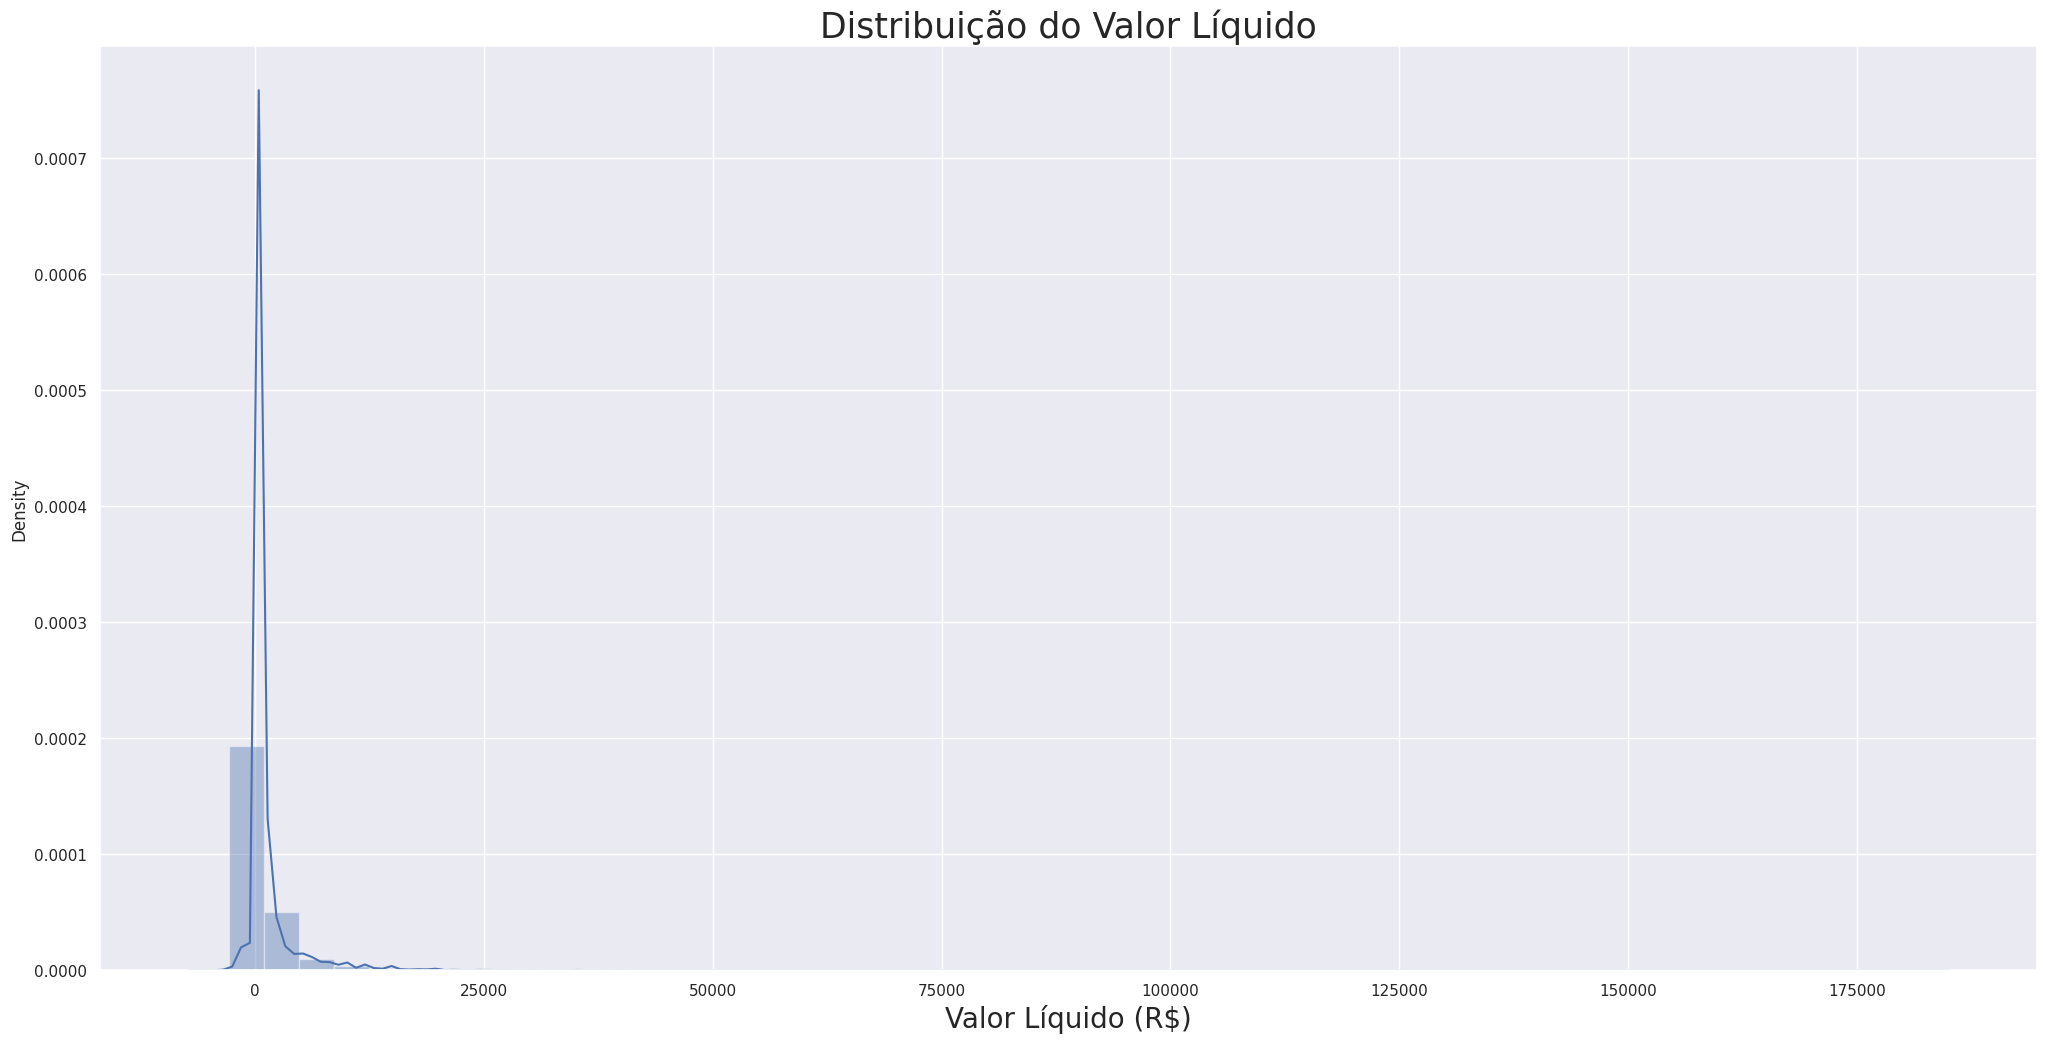

In [21]:
sns.distplot(df1['valor_liquido'])
plt.title('Distribuição do Valor Líquido', fontsize=25)
plt.xlabel('Valor Líquido (R$)', size=20);

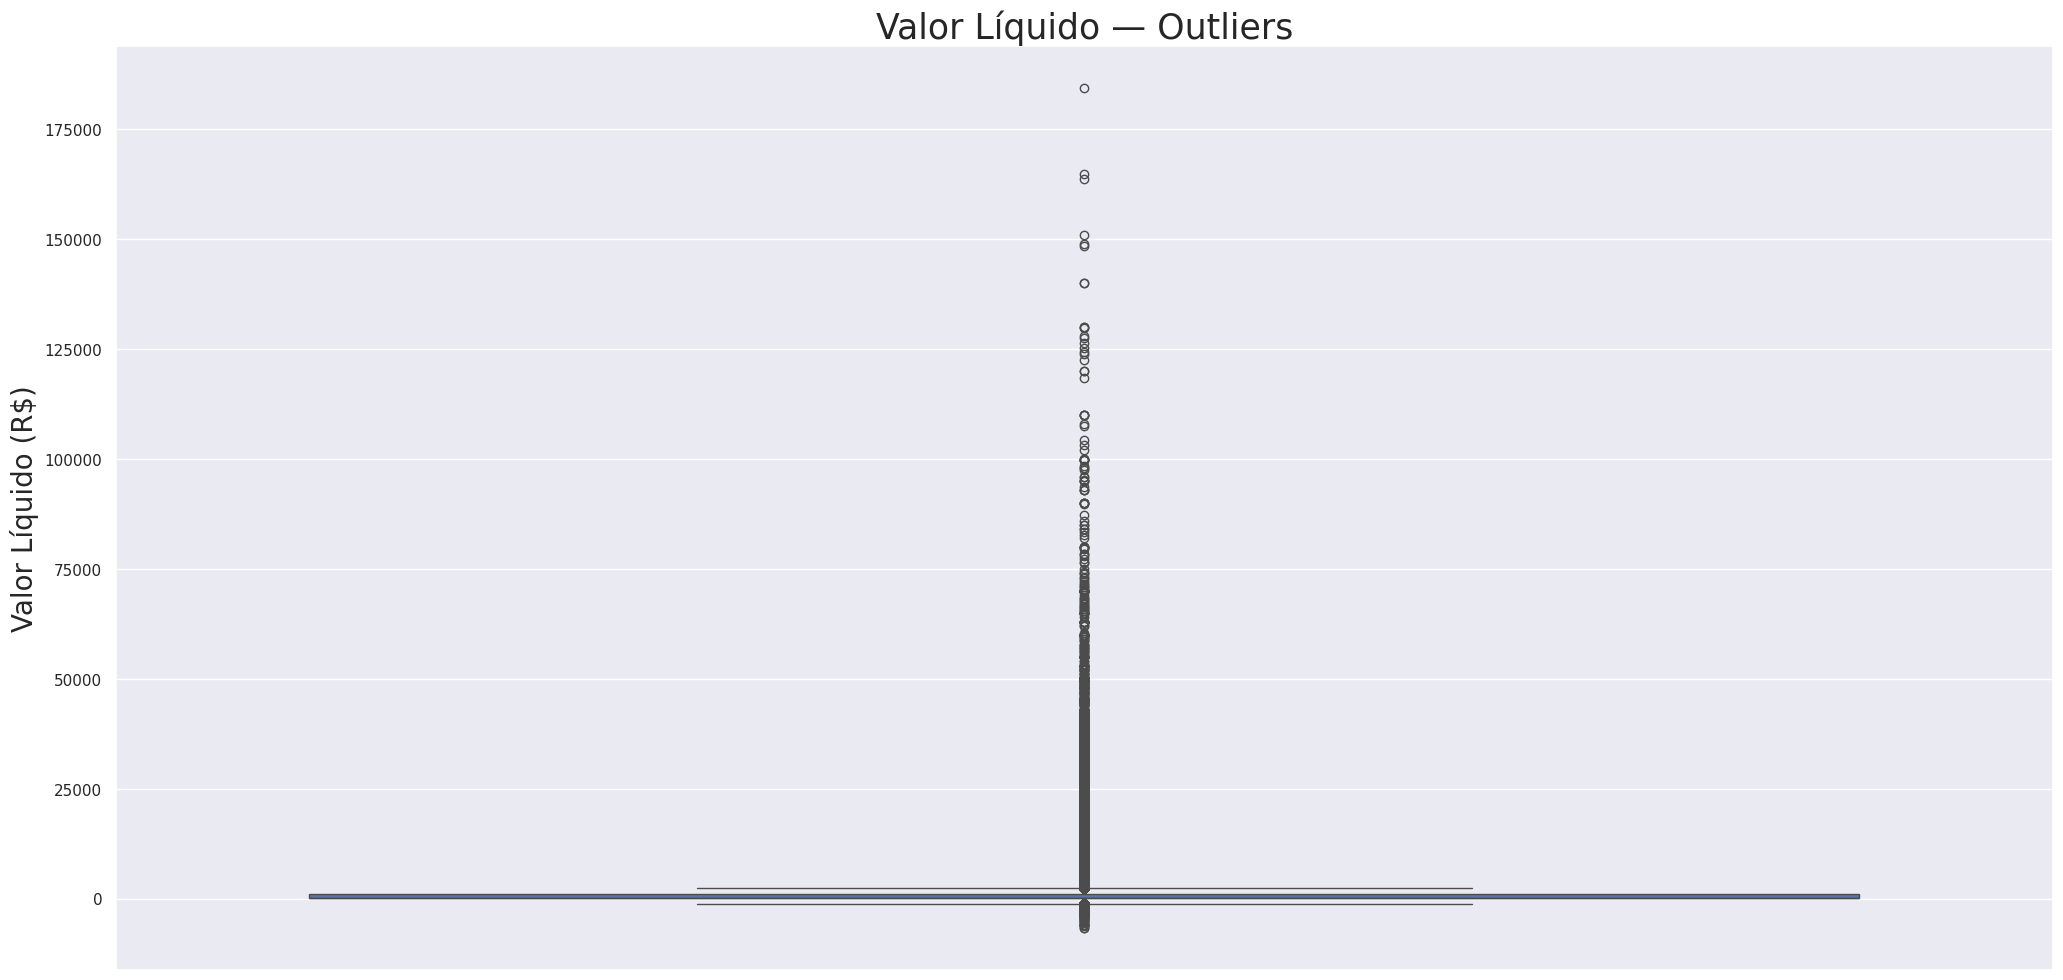

In [22]:
sns.boxplot(y='valor_liquido', data=df1).set_title('Valor Líquido — Outliers', fontsize=25)
plt.ylabel('Valor Líquido (R$)', size=20);

### **1.7.2 Categorical Attributes**

In [23]:
df1_cat.apply(lambda x: x.unique().shape[0])

,0
id_deputado,635
tipo_despesa,20
cod_documento,668649
nome_fornecedor,44985
cnpj_cpf_fornecedor,41724
num_documento,466161
url_documento,512497
nome,635
partido,23
uf,27


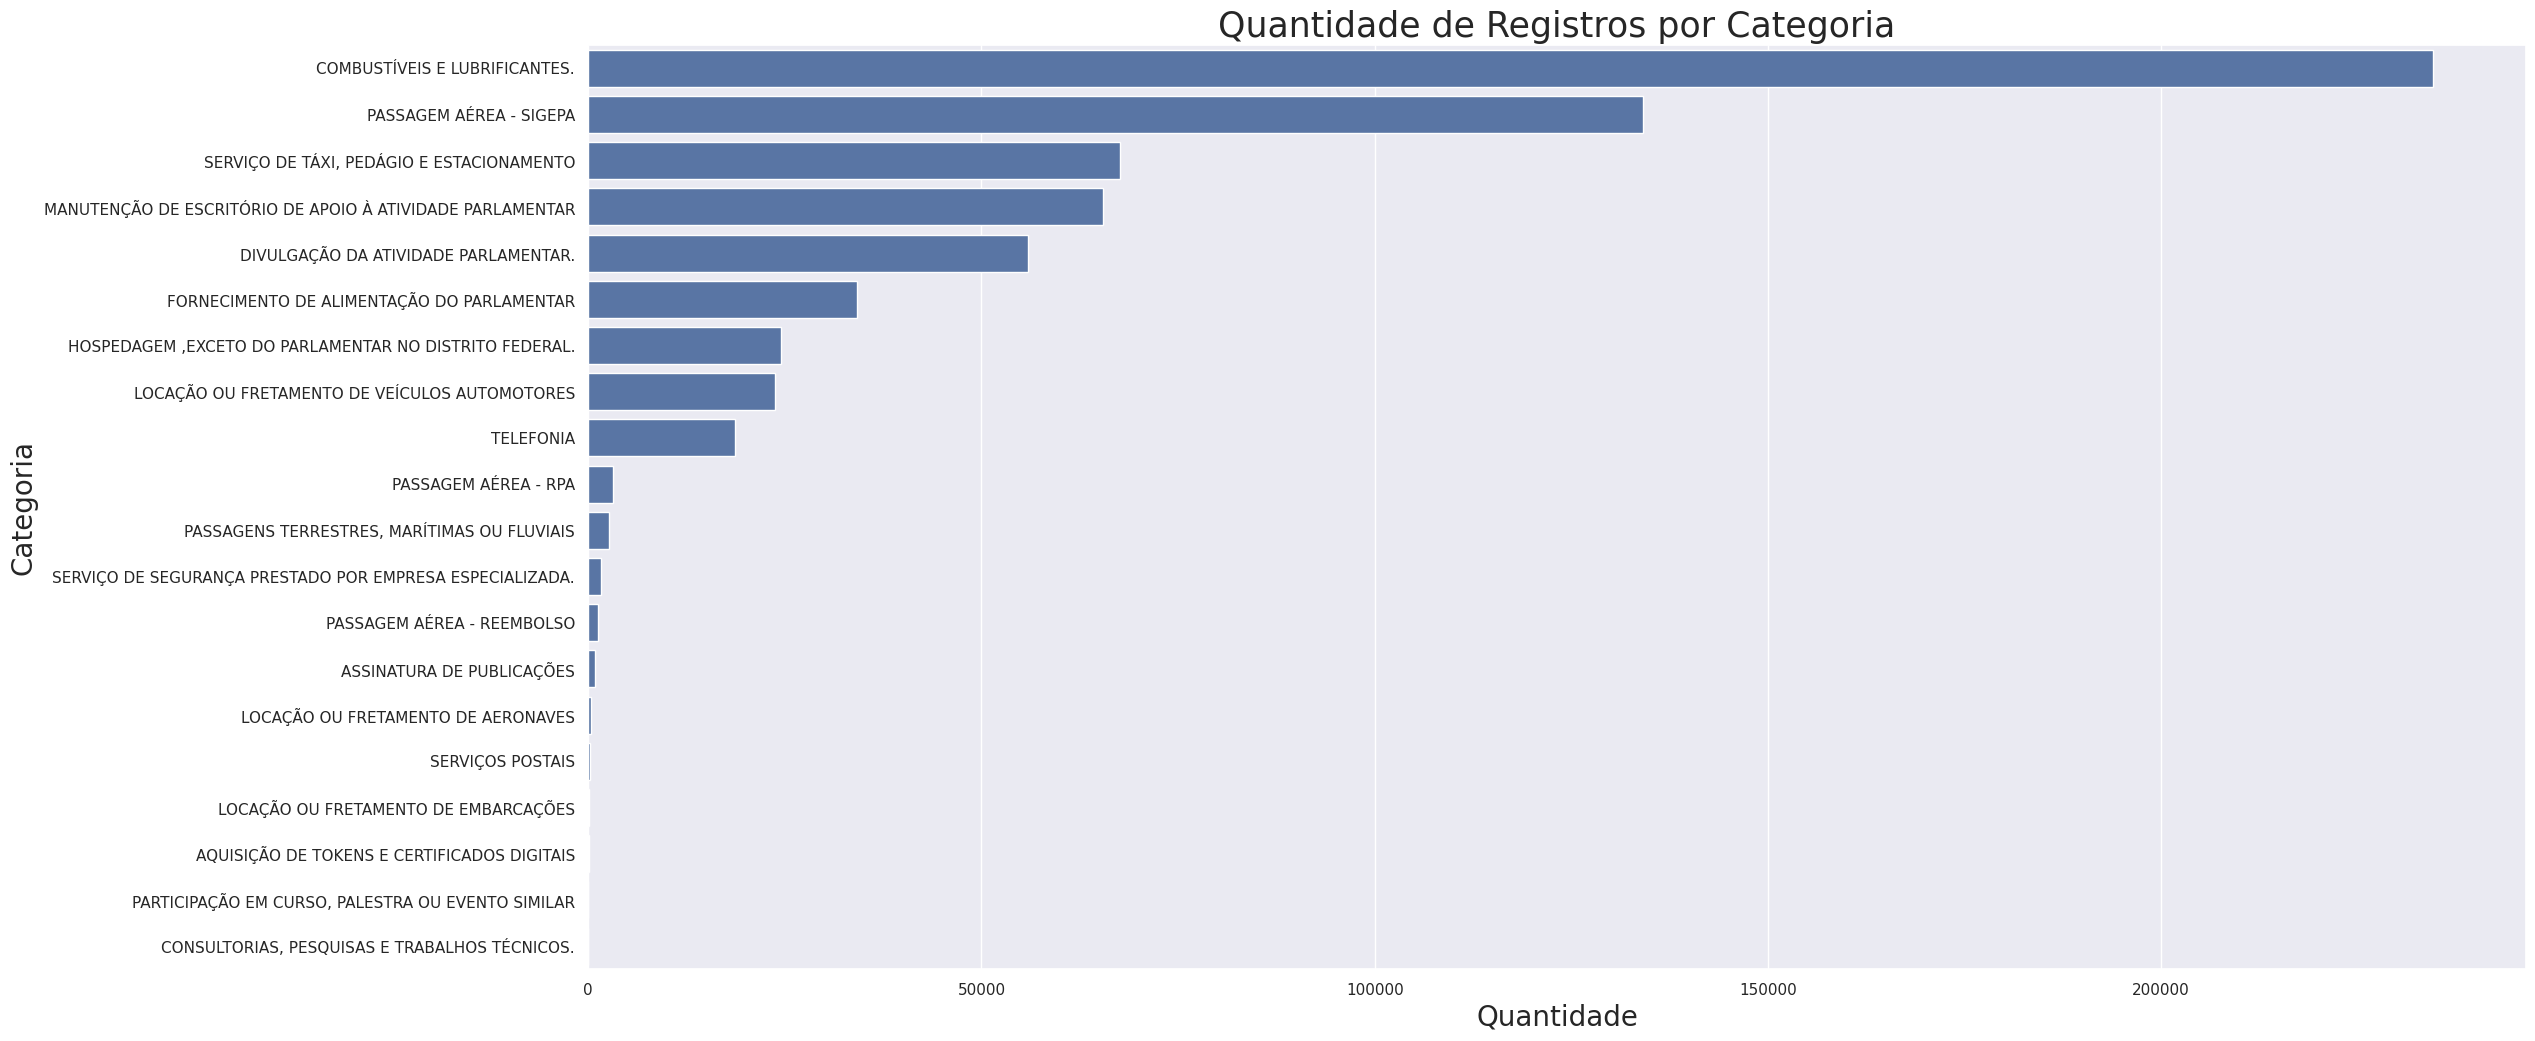

In [24]:
aux = df1[['tipo_despesa', 'valor_liquido']].groupby('tipo_despesa').count().reset_index()
sns.barplot(x='valor_liquido', y='tipo_despesa', data=aux.sort_values('valor_liquido', ascending=False))
plt.title('Quantidade de Registros por Categoria', fontsize=25)
plt.xlabel('Quantidade', size=20)
plt.ylabel('Categoria', size=20);

---
# **2.0 Feature Engineering**

In [25]:
df2 = df1.copy()

In [26]:
df2.sample(3)

,id_deputado,ano,mes,tipo_despesa,cod_documento,data_documento,valor_documento,valor_liquido,valor_glosa,nome_fornecedor,cnpj_cpf_fornecedor,num_documento,url_documento,nome,partido,uf
96534,213762,2025,4,COMBUSTÍVEIS E LUBRIFICANTES.,7908277,2025-04-10 00:00:00,100.0,100.0,0.0,ALECRIM COMERCIO LTDA,29327346000180.0,119167,http://www.camara.leg.br/cota-parlamentar/nota...,Carla Dickson,UNIÃO,RN
253401,204407,2025,6,COMBUSTÍVEIS E LUBRIFICANTES.,7931217,2025-06-09 15:33:28,58.9,58.9,0.0,EXXEN COMERCIO DE COMBUSTIVEIS LTDA,51032256000111.0,174654,http://www.camara.leg.br/cota-parlamentar/nota...,Fernanda Melchionna,PSOL,RS
323684,220696,2024,5,COMBUSTÍVEIS E LUBRIFICANTES.,7768280,2024-05-10 13:28:18,50.0,50.0,0.0,AUTO POSTO CASCALHEIRA LTDA,49930765000110.0,6501,http://www.camara.leg.br/cota-parlamentar/nota...,Ivoneide Caetano,PT,BA


## **2.1 Hypotheses List**

H1 - Combustíveis e passagens aéreas concentram a maior parte dos gastos parlamentares.

H2 - Deputados de estados mais distantes de Brasília gastam mais com passagens aéreas.

H3 - Partidos maiores gastam mais no total, mas não necessariamente mais por deputado.

H4 - Os gastos parlamentares aumentam no último ano da legislatura (2026).

H5 - Poucos fornecedores concentram a maior parte dos valores recebidos em cada categoria.

H6 - Existe um pequeno grupo de despesas com valores muito acima da mediana da categoria, que podem indicar superfaturamento.

H7 - A categoria de divulgação parlamentar apresenta maior dispersão de valores entre deputados do mesmo partido.

## **2.2 Feature Engineering**

In [27]:
# derivando variáveis da data
df2['year']  = df2['data_documento'].dt.year
df2['month'] = df2['data_documento'].dt.month
df2['day']   = df2['data_documento'].dt.day

In [28]:
df2.head(3)

,id_deputado,ano,mes,tipo_despesa,cod_documento,data_documento,valor_documento,valor_liquido,valor_glosa,nome_fornecedor,cnpj_cpf_fornecedor,num_documento,url_documento,nome,partido,uf,year,month,day
0,220593,2023,9,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7610066,2023-09-19,52.98,52.98,0.0,3XIS COMERCIO VAREJISTA E ATACADISTA DE PAPELA...,42999796000188.0,35537,http://www.camara.leg.br/cota-parlamentar/nota...,Abilio Brunini,PL,MT,2023,9,19
1,220593,2023,11,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7657491,2023-11-27,67.30,67.30,0.0,AGUAS CUIABA S.A,14995581000153.0,01,https://www.camara.leg.br/cota-parlamentar/doc...,Abilio Brunini,PL,MT,2023,11,27
2,220593,2023,5,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7552621,2023-05-05,43.20,43.20,0.0,AGUAS CUIABA S.A,14995581000153.0,11533052023001,https://www.camara.leg.br/cota-parlamentar/doc...,Abilio Brunini,PL,MT,2023,5,5


---
# **3.0 Data Filtering**

In [29]:
df3 = df2.copy()

## **3.1 Filtragem das Linhas**

In [30]:
# separando estornos (valores negativos) para análise específica
df3_estornos = df3[df3['valor_liquido'] < 0].copy()
df3          = df3[df3['valor_liquido'] >= 0].copy()

print('Estornos separados    : {}'.format(len(df3_estornos)))
print('Registros para análise: {}'.format(len(df3)))
print('Valor mínimo após filtro: {}'.format(df3['valor_liquido'].min()))

Estornos separados    : 26642
Registros para análise: 642269
Valor mínimo após filtro: -0.0


## **3.2 Seleção das Colunas**

In [31]:
df3.sample(3)

,id_deputado,ano,mes,tipo_despesa,cod_documento,data_documento,valor_documento,valor_liquido,valor_glosa,nome_fornecedor,cnpj_cpf_fornecedor,num_documento,url_documento,nome,partido,uf,year,month,day
102525,204460,2023,9,PASSAGEM AÉREA - SIGEPA,189296,2023-09-19 12:00:00,1367.51,1367.51,0.0,TAM,NAO INFORMADO,9572125774512,NAO INFORMADO,Carlos Jordy,PL,RJ,2023,9,19
137467,220595,2024,9,COMBUSTÍVEIS E LUBRIFICANTES.,7838177,2024-09-05 00:00:00,380.71,380.71,0.0,COMERCIO DE DERIVADOS DE PETROLEO LN LTDA III,33013554000344.0,135116,https://www.camara.leg.br/cota-parlamentar/doc...,Coronel Fernanda,PL,MT,2024,9,5
449246,74398,2023,2,TELEFONIA,7504296,2023-02-21 00:00:00,251.90,251.90,0.0,CLARO S/A,40432544010100.0,63567762,NAO INFORMADO,Maria do Rosário,PT,RS,2023,2,21


---
# **4.0 EDA**

In [32]:
df4 = df3.copy()

## **4.1 Análise Univariada**

**descrever a distribuição de uma única variável**

In [33]:
df4.columns

Index(['id_deputado', 'ano', 'mes', 'tipo_despesa', 'cod_documento',
       'data_documento', 'valor_documento', 'valor_liquido', 'valor_glosa',
       'nome_fornecedor', 'cnpj_cpf_fornecedor', 'num_documento',
       'url_documento', 'nome', 'partido', 'uf', 'year', 'month', 'day'],
      dtype='object')

##### **• Tipo de Despesa**

In [34]:
aux = df4[['tipo_despesa', 'valor_liquido']].groupby('tipo_despesa').sum().reset_index()

fig = px.bar(aux.sort_values('valor_liquido', ascending=True),
             x='valor_liquido', y='tipo_despesa', orientation='h',
             title='Valor Total por Categoria de Despesa')
fig.show()

##### **• Valor Líquido**

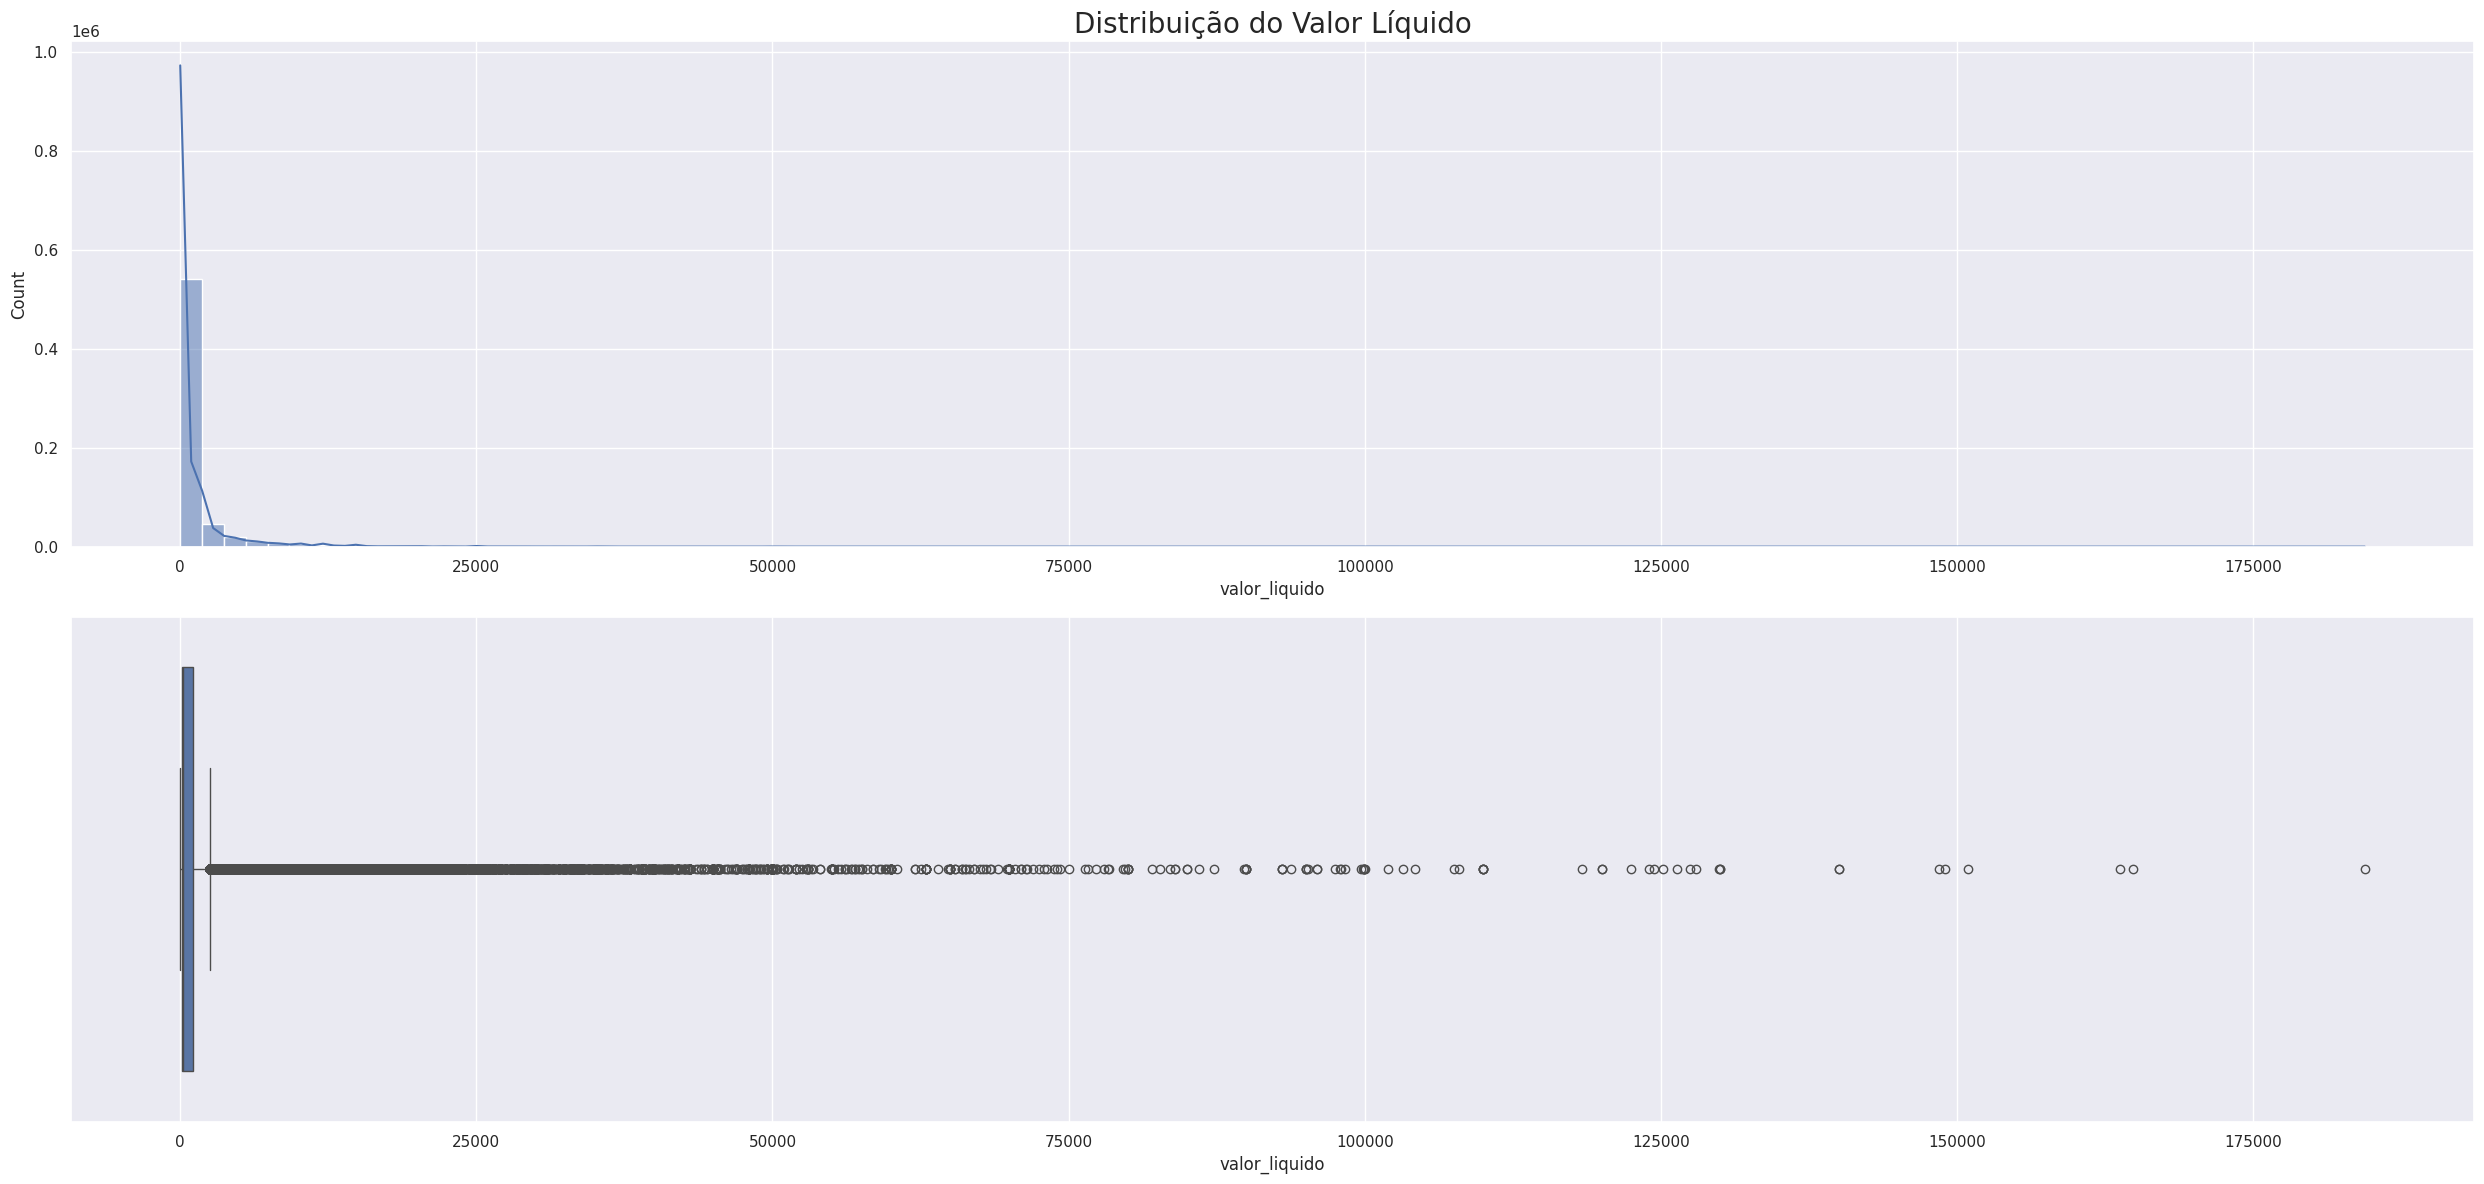

In [35]:
plt.subplot(2, 1, 1)
sns.histplot(df4['valor_liquido'], bins=100, kde=True)
plt.title('Distribuição do Valor Líquido', fontsize=20)

plt.subplot(2, 1, 2)
sns.boxplot(x='valor_liquido', data=df4)
plt.tight_layout();

##### **• Partido**

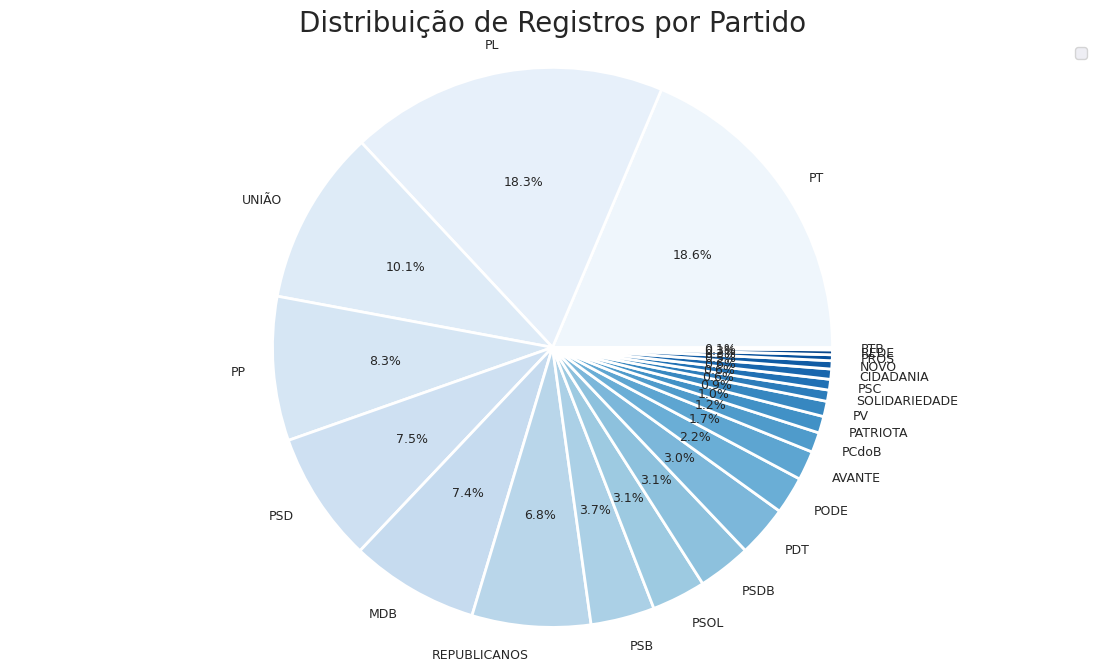

In [36]:
count = df4['partido'].value_counts().values
X     = df4['partido'].value_counts().index

plt.figure(figsize=(14, 8))
plt.pie(count,
        labels=list(X),
        colors=sns.color_palette('Blues', len(X)),
        autopct='%1.1f%%',
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
        textprops={'fontsize': 9})
plt.axis('equal')
plt.title('Distribuição de Registros por Partido', fontsize=20)
plt.legend('');

##### **• UF**

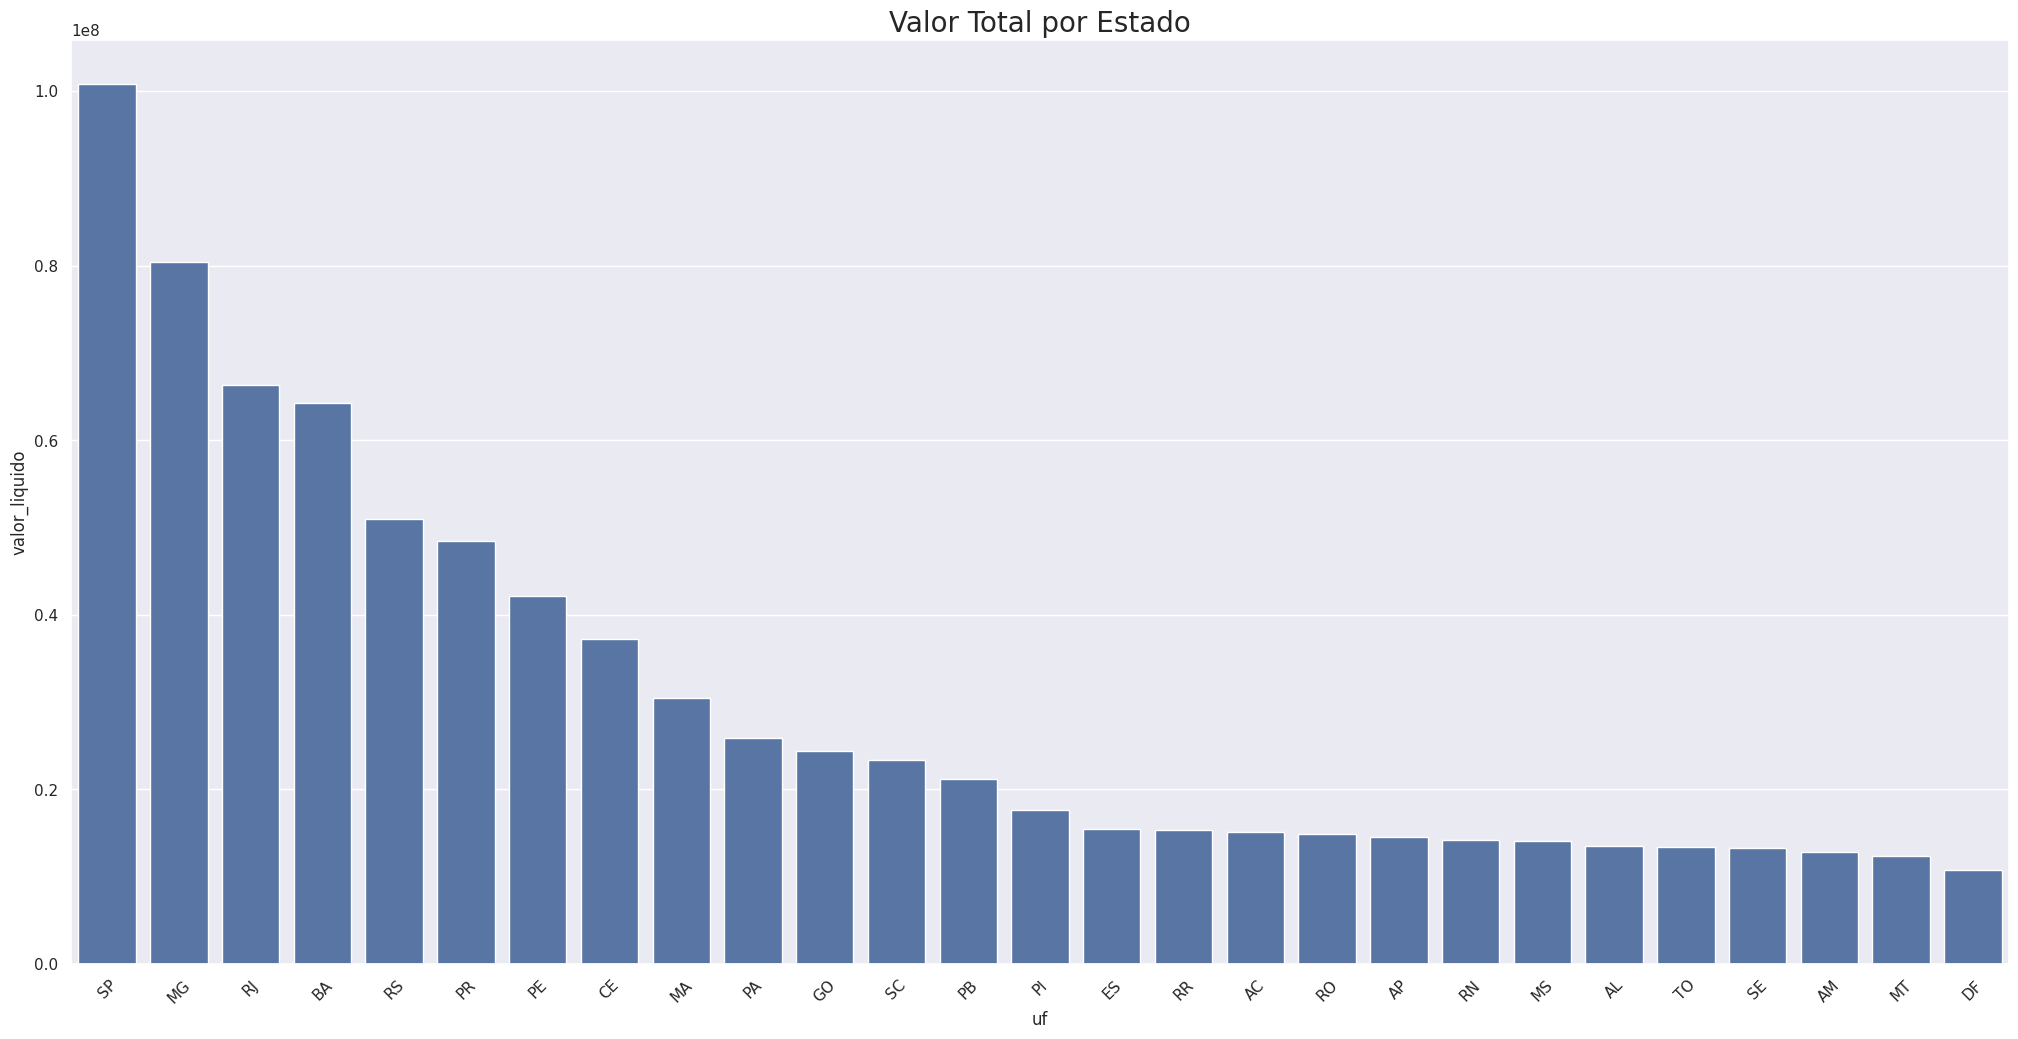

In [37]:
aux_uf = df4[['uf', 'valor_liquido']].groupby('uf').sum().reset_index().sort_values('valor_liquido', ascending=False)
sns.barplot(x='uf', y='valor_liquido', data=aux_uf)
plt.title('Valor Total por Estado', fontsize=20)
plt.xticks(rotation=45);

### **4.1.2 Numerical Attributes**

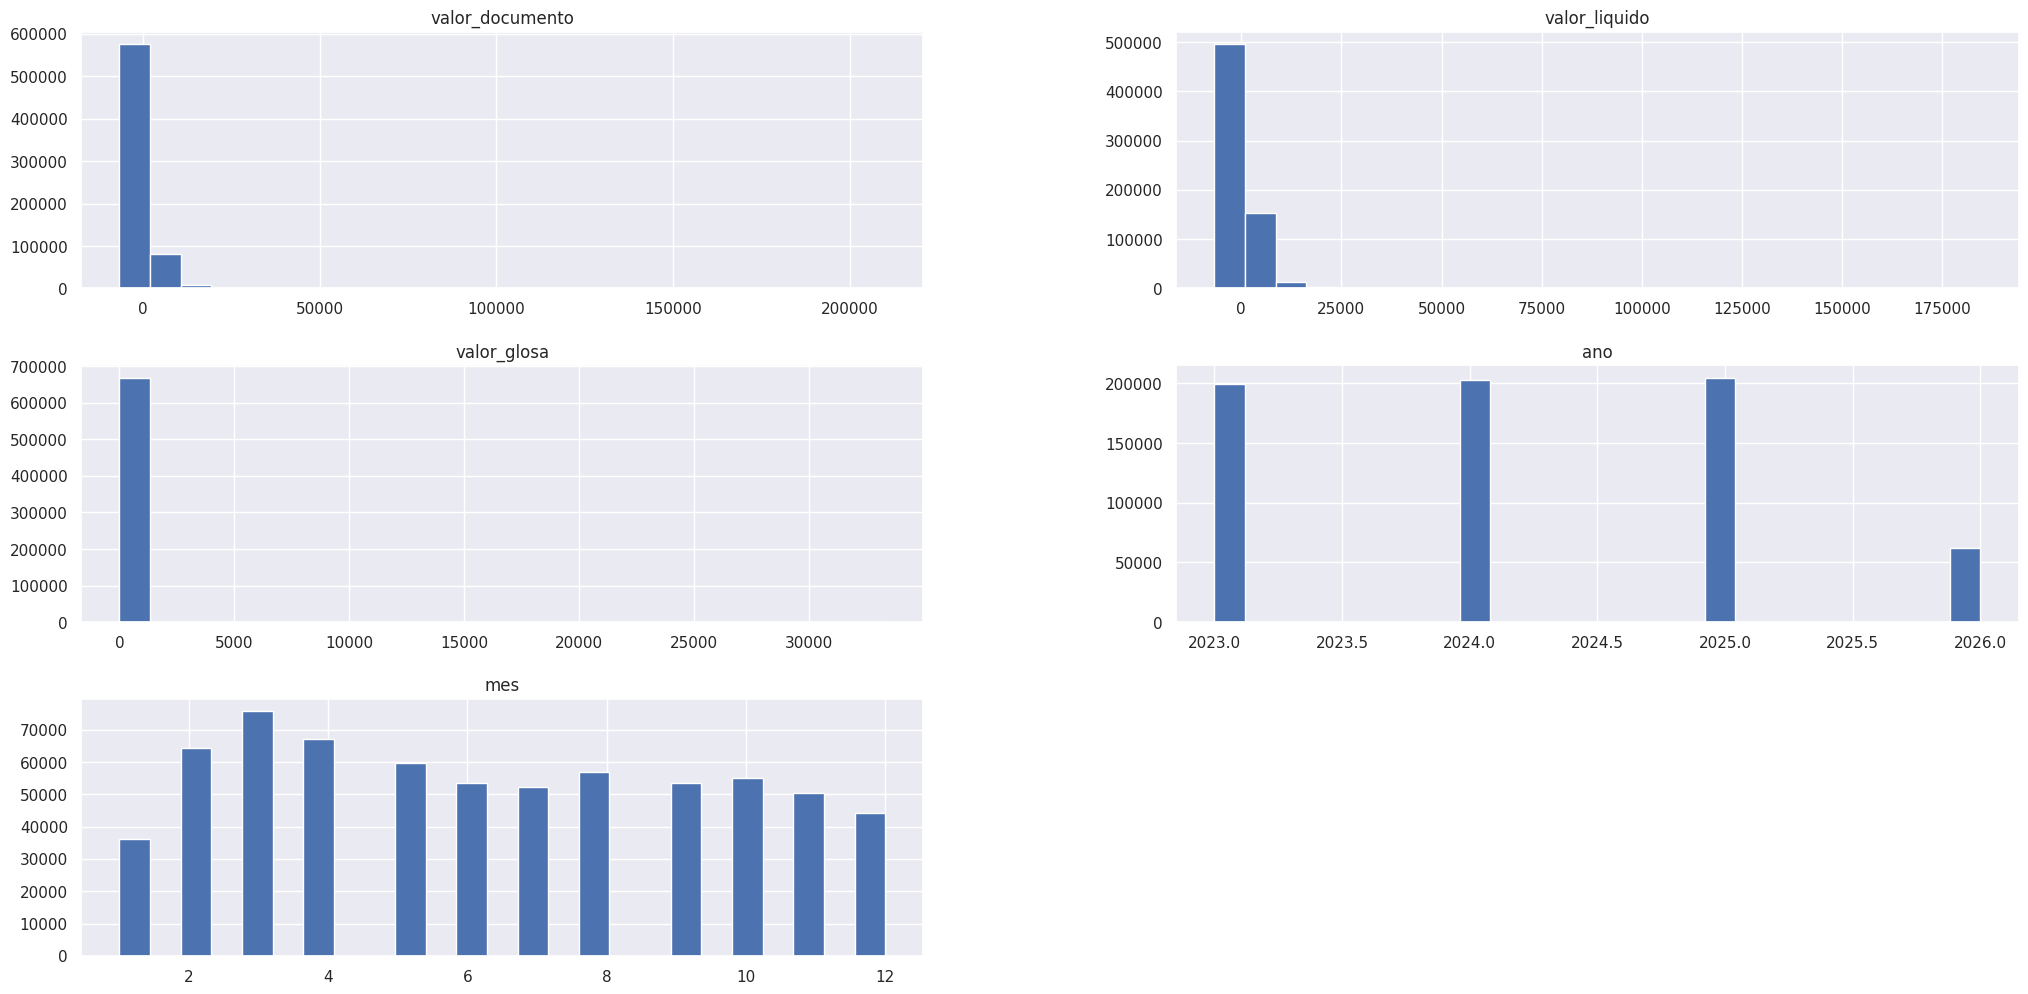

In [38]:
df1_num.hist(bins=25);

### **4.1.3 Categorical Attributes**

In [39]:
df1_cat.head()

,id_deputado,tipo_despesa,cod_documento,nome_fornecedor,cnpj_cpf_fornecedor,num_documento,url_documento,nome,partido,uf
0,220593,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7610066,3XIS COMERCIO VAREJISTA E ATACADISTA DE PAPELA...,42999796000188.0,35537,http://www.camara.leg.br/cota-parlamentar/nota...,Abilio Brunini,PL,MT
1,220593,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7657491,AGUAS CUIABA S.A,14995581000153.0,01,https://www.camara.leg.br/cota-parlamentar/doc...,Abilio Brunini,PL,MT
2,220593,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7552621,AGUAS CUIABA S.A,14995581000153.0,11533052023001,https://www.camara.leg.br/cota-parlamentar/doc...,Abilio Brunini,PL,MT
3,220593,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7587236,AGUAS CUIABA S.A,14995581000153.0,11533062023001,https://www.camara.leg.br/cota-parlamentar/doc...,Abilio Brunini,PL,MT
4,220593,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7587239,AGUAS CUIABA S.A,14995581000153.0,11533072023001,https://www.camara.leg.br/cota-parlamentar/doc...,Abilio Brunini,PL,MT


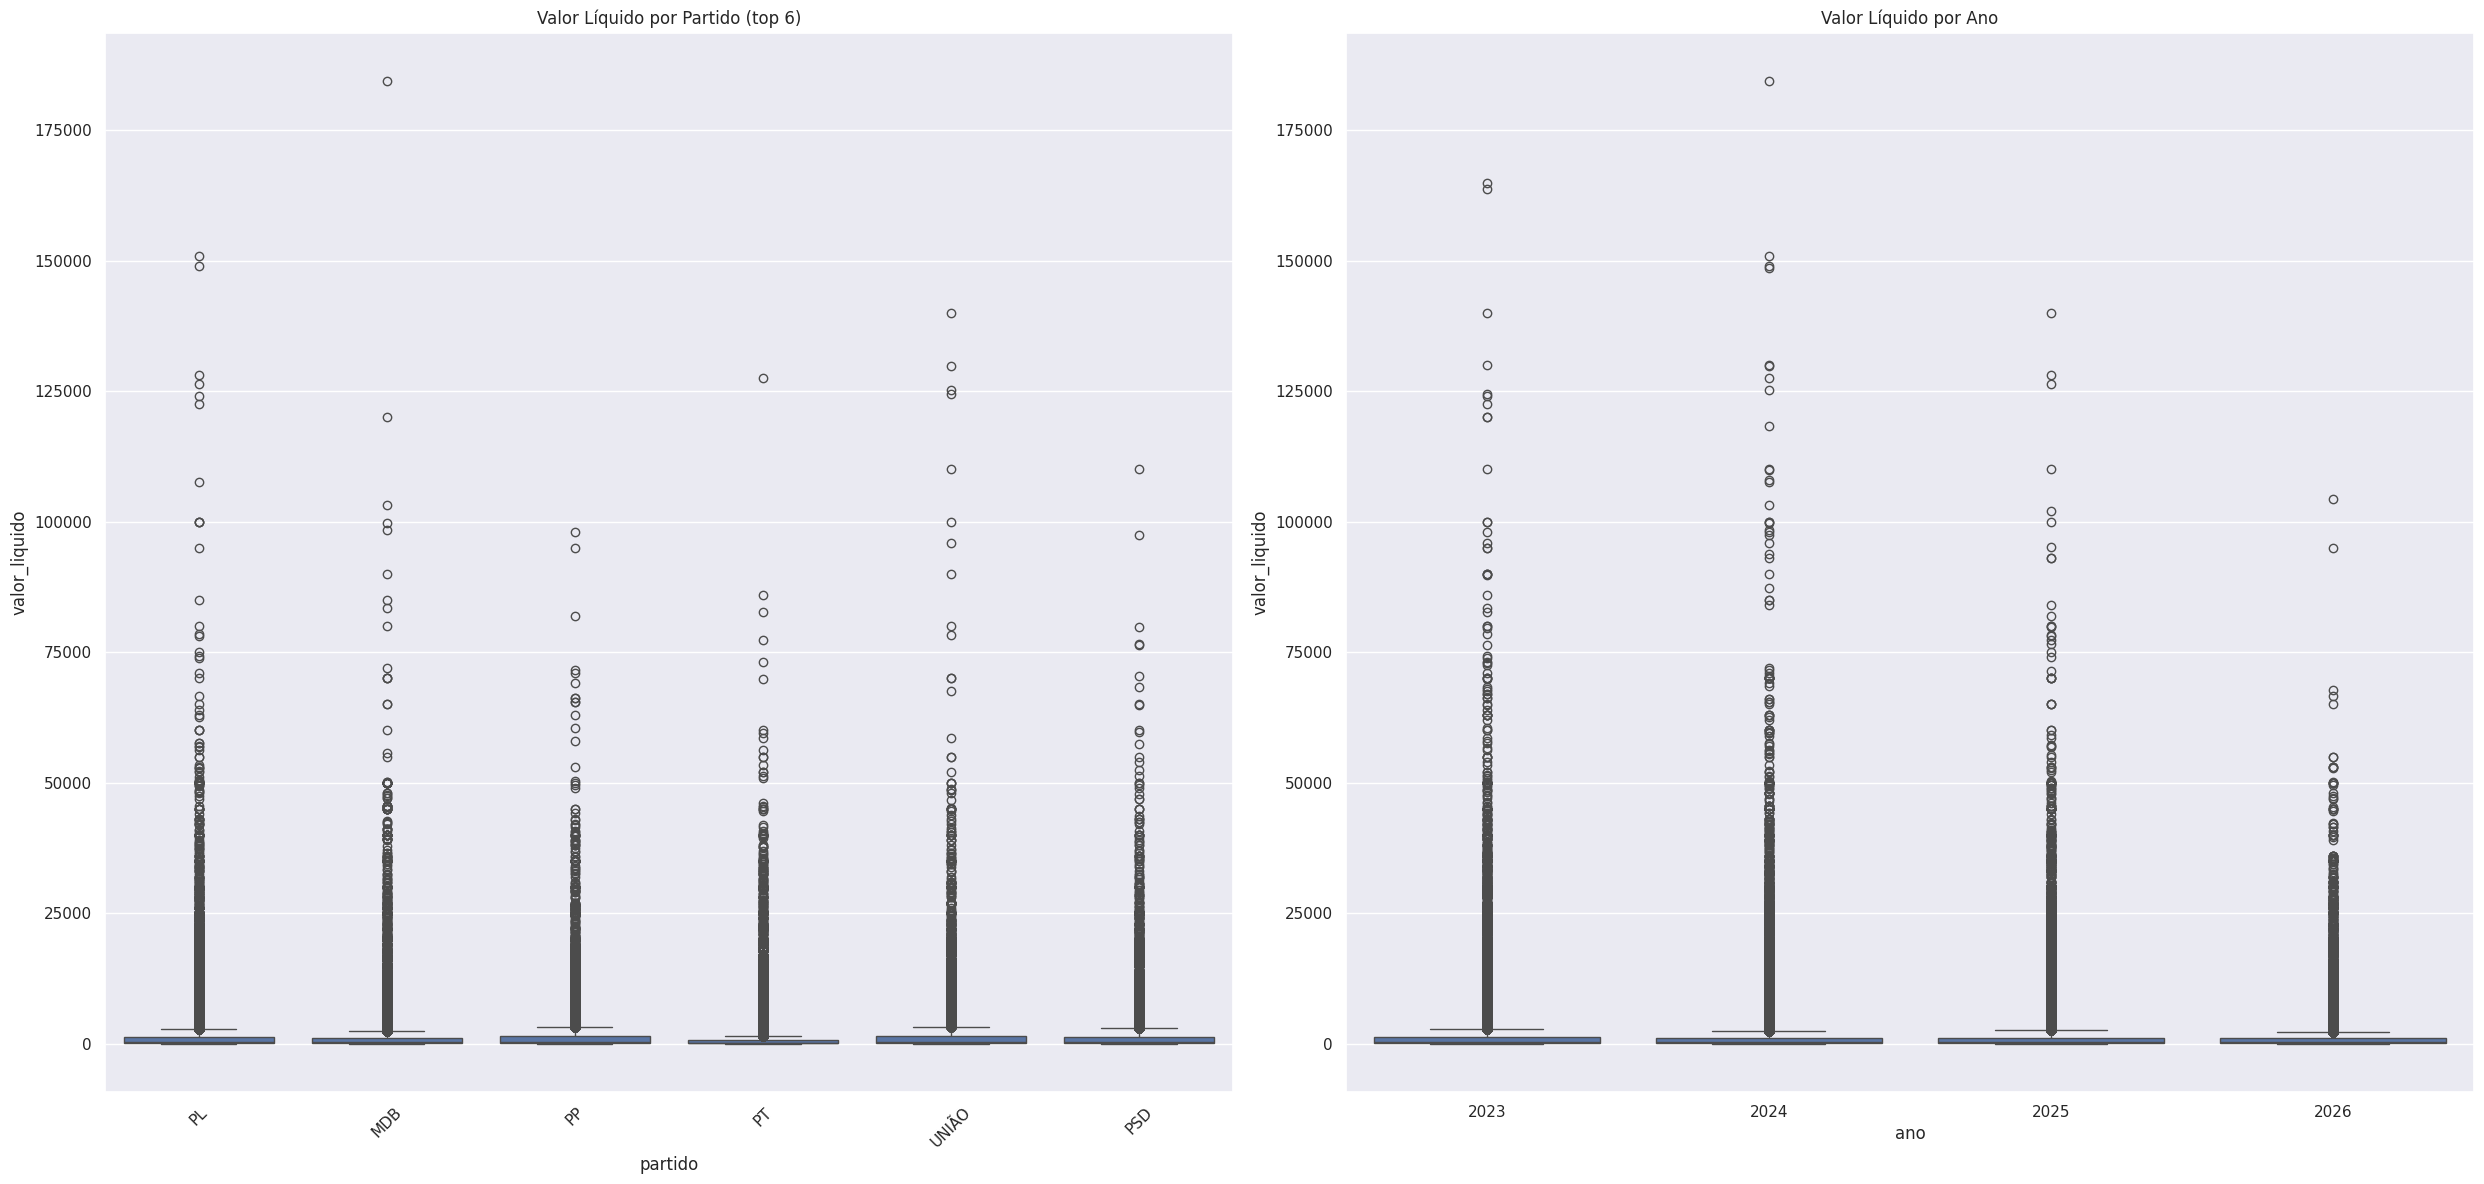

In [40]:
plt.subplot(1, 2, 1)
sns.boxplot(x='partido', y='valor_liquido',
            data=df4[df4['partido'].isin(df4['partido'].value_counts().head(6).index)])
plt.xticks(rotation=45)
plt.title('Valor Líquido por Partido (top 6)')

plt.subplot(1, 2, 2)
sns.boxplot(x='ano', y='valor_liquido', data=df4)
plt.title('Valor Líquido por Ano')
plt.tight_layout();

## **4.2 Análise Bivariada**

**descrever a associação entre duas variáveis**

**validação das hipóteses**

##### **H1 - Combustíveis e passagens aéreas concentram a maior parte dos gastos parlamentares.**
Resposta: Apesar das passagens aéreas (SIGEPA) representam 15,69% do total, e combustíveis 8,86%, somando cerca de 24% juntos, a categoria que dominou os gastos foi Divulgação da Atividade Parlamentar, com 40,37% do total gasto, quase o dobro de todas as modalidades de passagem somadas. Isso mostra que o maior volume de recursos públicos vai para comunicação e publicidade parlamentar e não para deslocamento.

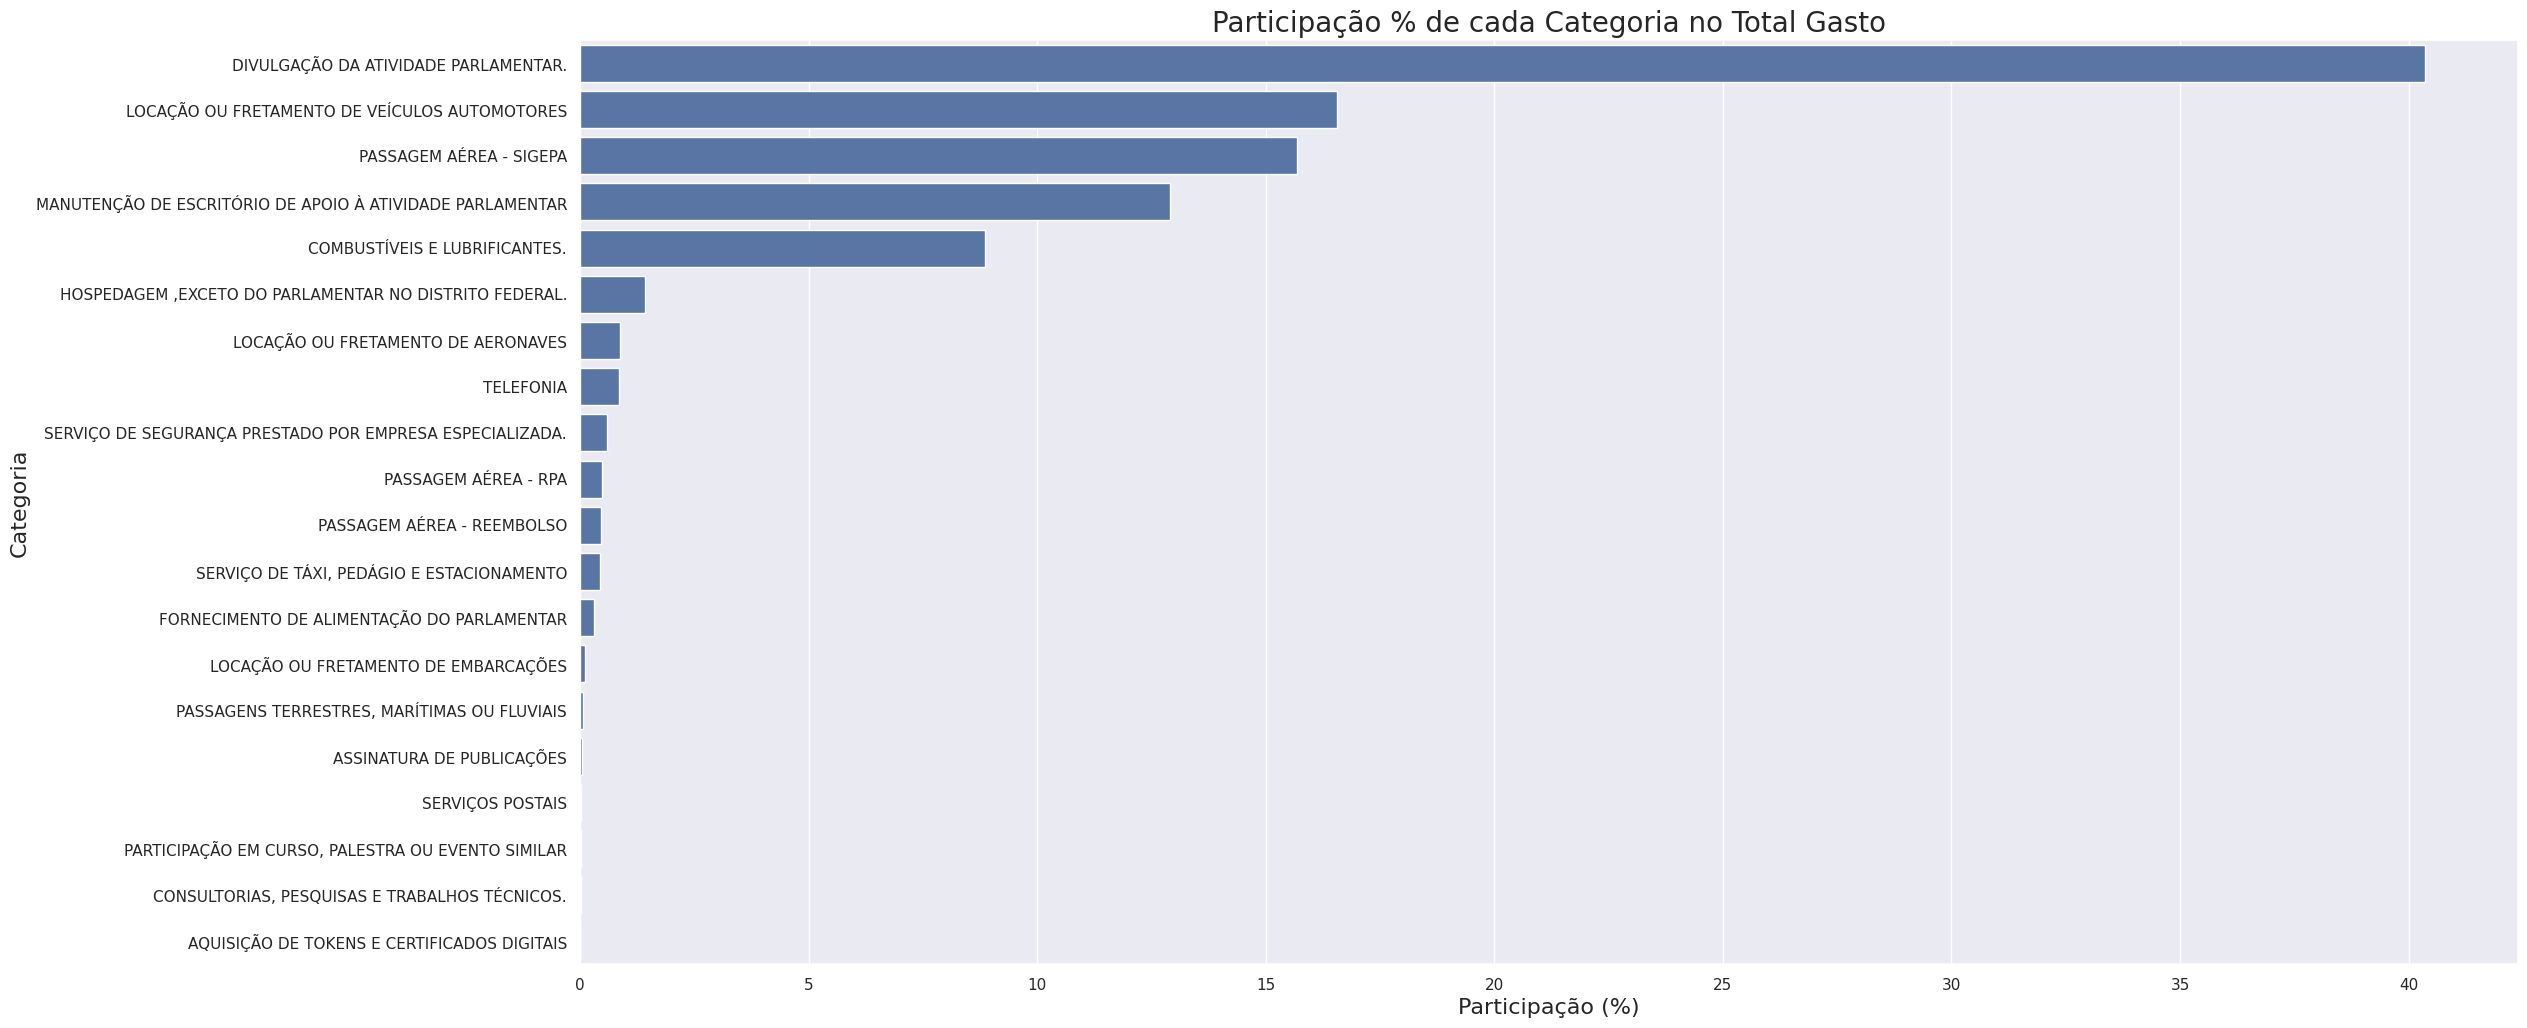

In [41]:
aux1 = df4[['tipo_despesa', 'valor_liquido']].groupby('tipo_despesa').sum().reset_index()
aux1['perc'] = (aux1['valor_liquido'] / aux1['valor_liquido'].sum() * 100).round(2)
aux1 = aux1.sort_values('valor_liquido', ascending=False)

sns.barplot(x='perc', y='tipo_despesa', data=aux1)
plt.title('Participação % de cada Categoria no Total Gasto', fontsize=20)
plt.xlabel('Participação (%)', size=16)
plt.ylabel('Categoria', size=16);

In [42]:
aux1[['tipo_despesa', 'valor_liquido', 'perc']]

,tipo_despesa,valor_liquido,perc
4,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,3.283753e+08,40.37
9,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,1.346449e+08,16.55
14,PASSAGEM AÉREA - SIGEPA,1.275767e+08,15.69
10,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,1.049202e+08,12.90
2,COMBUSTÍVEIS E LUBRIFICANTES.,7.203610e+07,8.86
6,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ...",1.150818e+07,1.41
7,LOCAÇÃO OU FRETAMENTO DE AERONAVES,7.145129e+06,0.88
19,TELEFONIA,6.896125e+06,0.85
16,SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPE...,4.725967e+06,0.58
13,PASSAGEM AÉREA - RPA,3.870054e+06,0.48


##### **H2 - Deputados de estados mais distantes de Brasília gastam mais com passagens aéreas.**
Resposta: Não. O Amazonas está na frente com o gasto
médio com passagens (~R$1.690), o que seria esperado pela distância. Porém o
Distrito Federal aparece em
segundo lugar com média próxima de R$1.660. Estados próximos como AL e TO
também apresentam valores altos, enquanto estados distantes como RS, PR e SP
ficam entre os menores. A distância geográfica não é o único fator determinante.

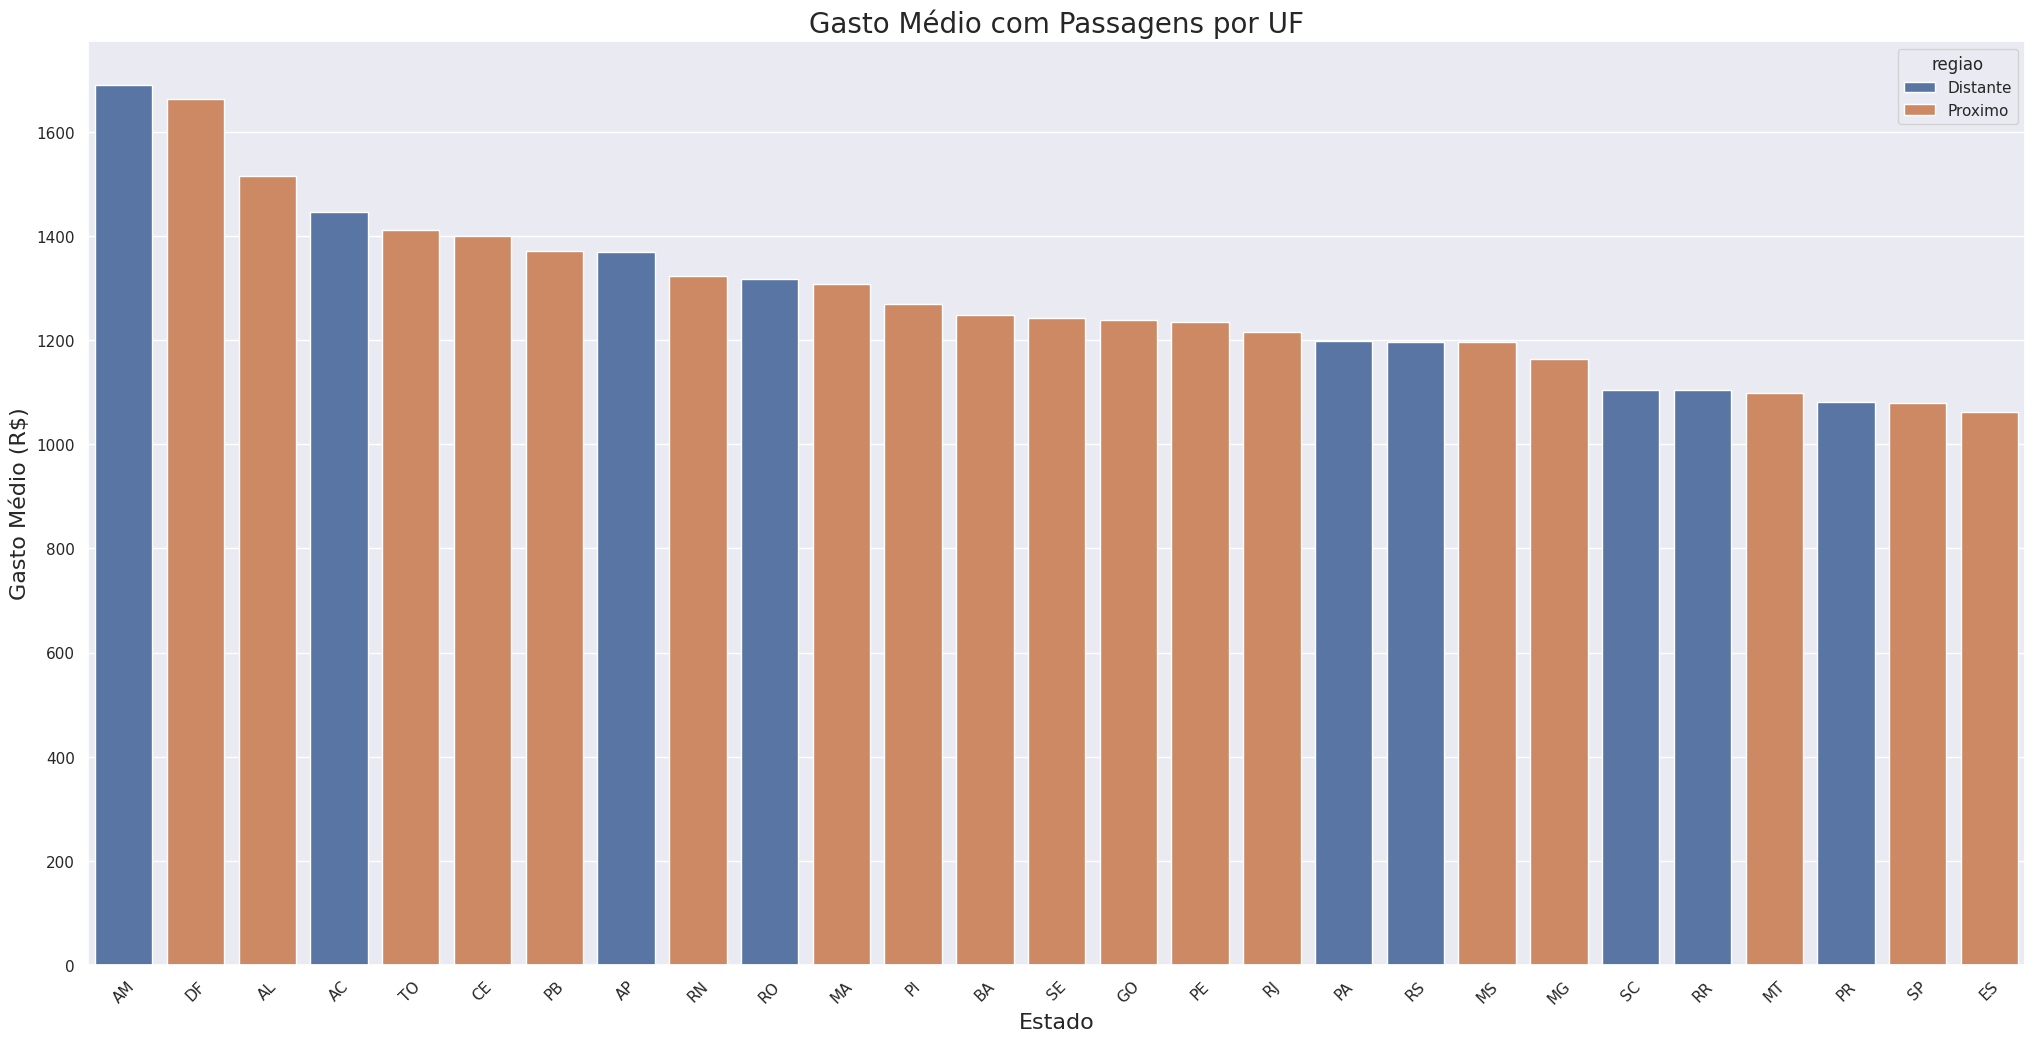

In [43]:
estados_distantes = ['AM', 'PA', 'RR', 'AP', 'AC', 'RO', 'RS', 'SC', 'PR']

aux2 = df4[df4['tipo_despesa'].str.contains('PASSAGEM', na=False)].copy()
aux2['regiao'] = aux2['uf'].apply(lambda x: 'Distante' if x in estados_distantes else 'Proximo')

aux2_grupo = aux2.groupby(['uf', 'regiao'])['valor_liquido'].mean().reset_index()

sns.barplot(x='uf', y='valor_liquido', hue='regiao',
            data=aux2_grupo.sort_values('valor_liquido', ascending=False))
plt.title('Gasto Médio com Passagens por UF', fontsize=20)
plt.xticks(rotation=45)
plt.xlabel('Estado', size=16)
plt.ylabel('Gasto Médio (R$)', size=16);

##### **H3 - Partidos maiores gastam mais no total, mas não necessariamente mais por deputado.**
Resposta: Sim. O PL esta a frente no total absoluto
(R$150M), seguido por PT (R$110M) e União Brasil (R$94M), refletindo o
tamanho das bancadas. No ranking de gasto médio por deputado, o topo é ocupado
por PV, PTB e PROS, partidos
menores em que
deputados individualmente gastam mais. Tamanho da bancada e eficiência no uso
da cota são dimensões independentes.

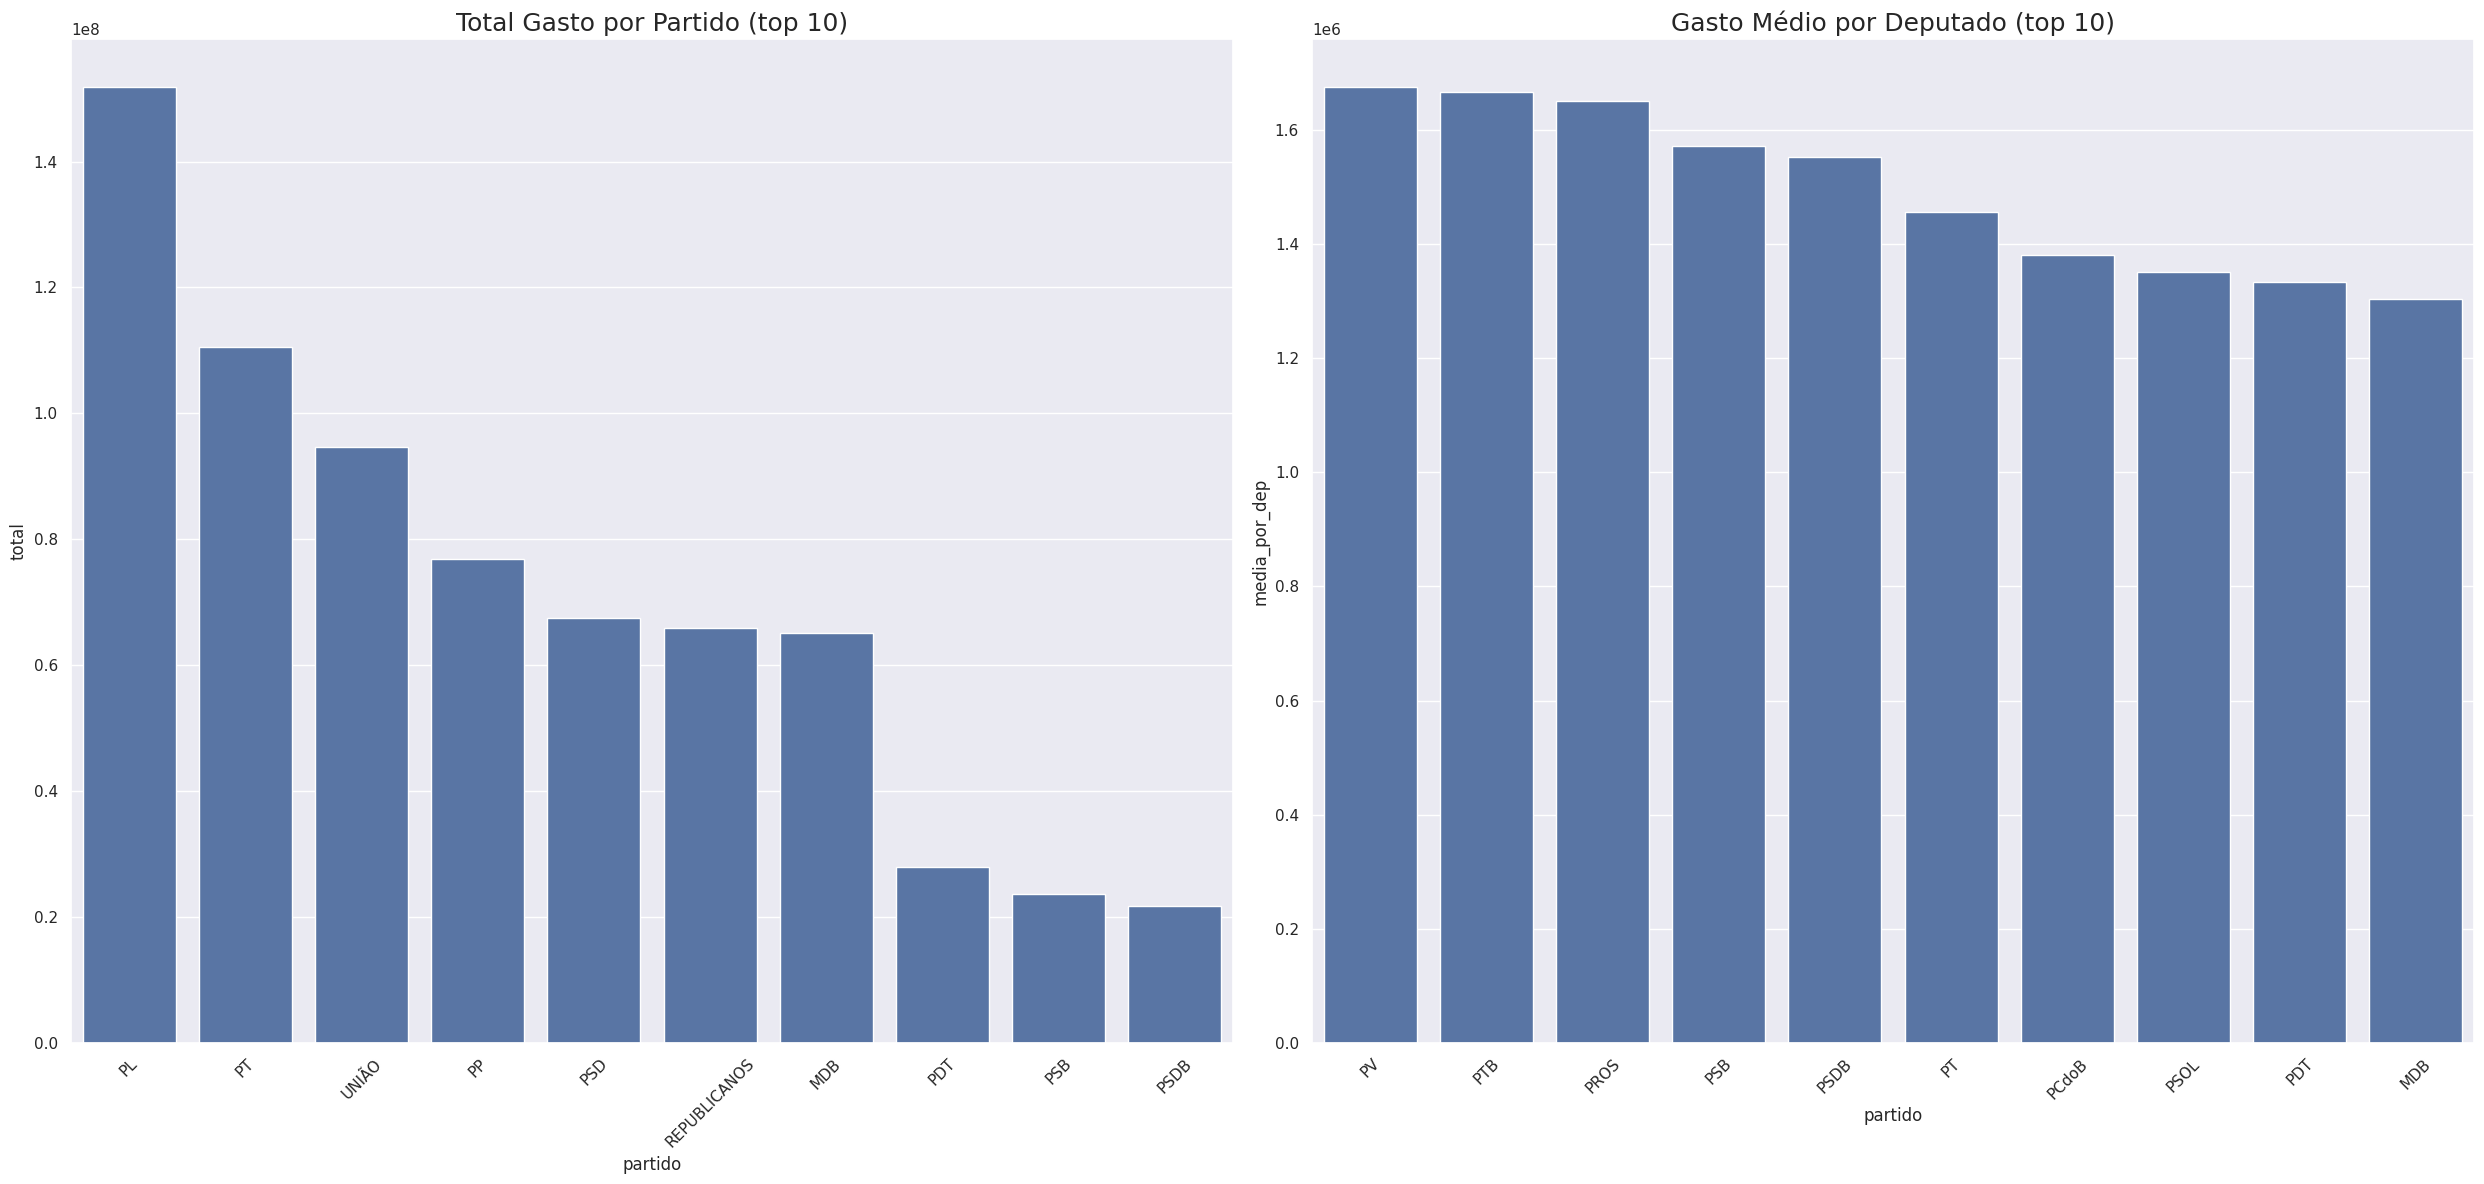

In [44]:
aux3_total = df4.groupby('partido')['valor_liquido'].sum().reset_index()
aux3_total.columns = ['partido', 'total']

aux3_media = (df4.groupby(['partido', 'id_deputado'])['valor_liquido']
                .sum().reset_index()
                .groupby('partido')['valor_liquido']
                .mean().reset_index())
aux3_media.columns = ['partido', 'media_por_dep']

plt.subplot(1, 2, 1)
sns.barplot(x='partido', y='total',
            data=aux3_total.sort_values('total', ascending=False).head(10))
plt.title('Total Gasto por Partido (top 10)', fontsize=18)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x='partido', y='media_por_dep',
            data=aux3_media.sort_values('media_por_dep', ascending=False).head(10))
plt.title('Gasto Médio por Deputado (top 10)', fontsize=18)
plt.xticks(rotation=45)

plt.tight_layout();

##### **H4 - Os gastos parlamentares aumentam no último ano da legislatura (2026).**
O maior gasto anual foi em
2025 (R$254M). Os dados de 2026 estão incompletos, abrangem apenas os primeiros meses, o que explica o valor menor
mostrado. A hipótese
não pode ser confirmada até o encerramento do ano.

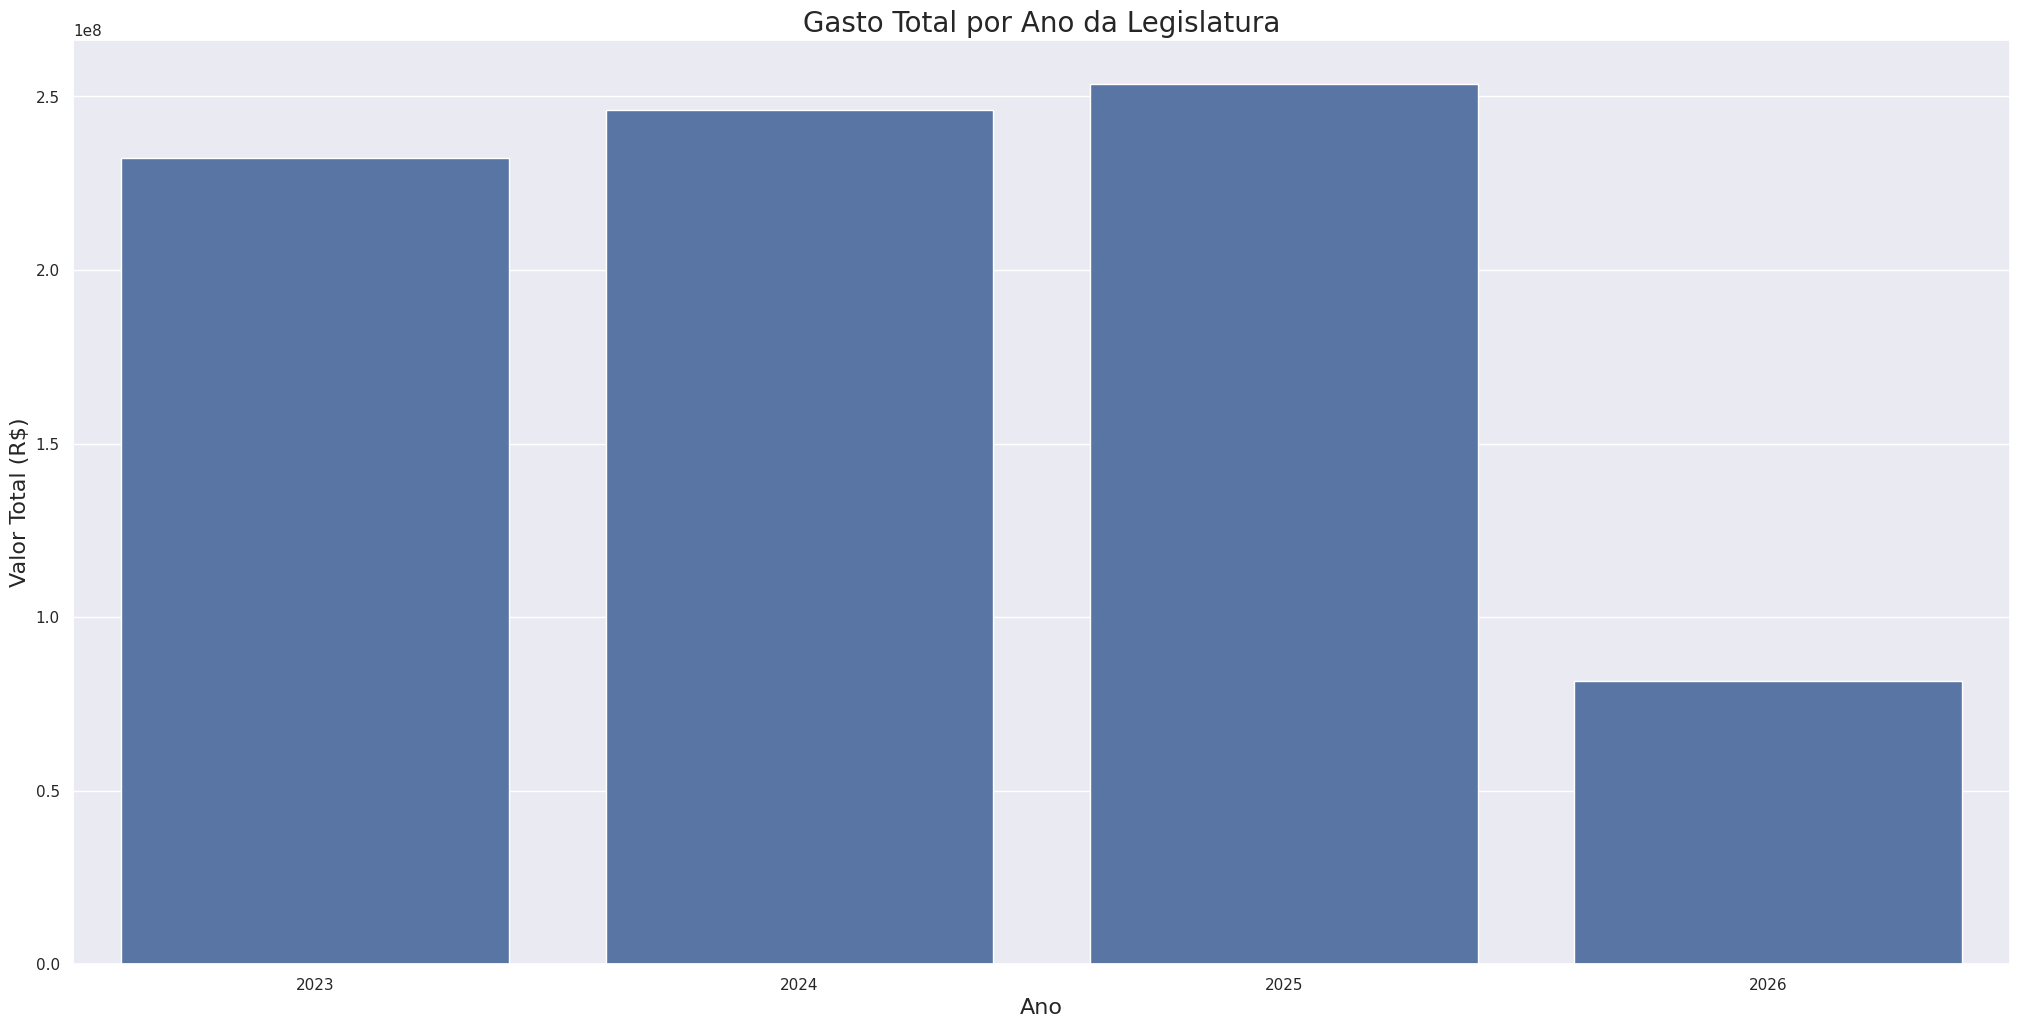

In [45]:
aux4 = df4.groupby('ano')['valor_liquido'].sum().reset_index()

sns.barplot(x='ano', y='valor_liquido', data=aux4)
plt.title('Gasto Total por Ano da Legislatura', fontsize=20)
plt.xlabel('Ano', size=16)
plt.ylabel('Valor Total (R$)', size=16);

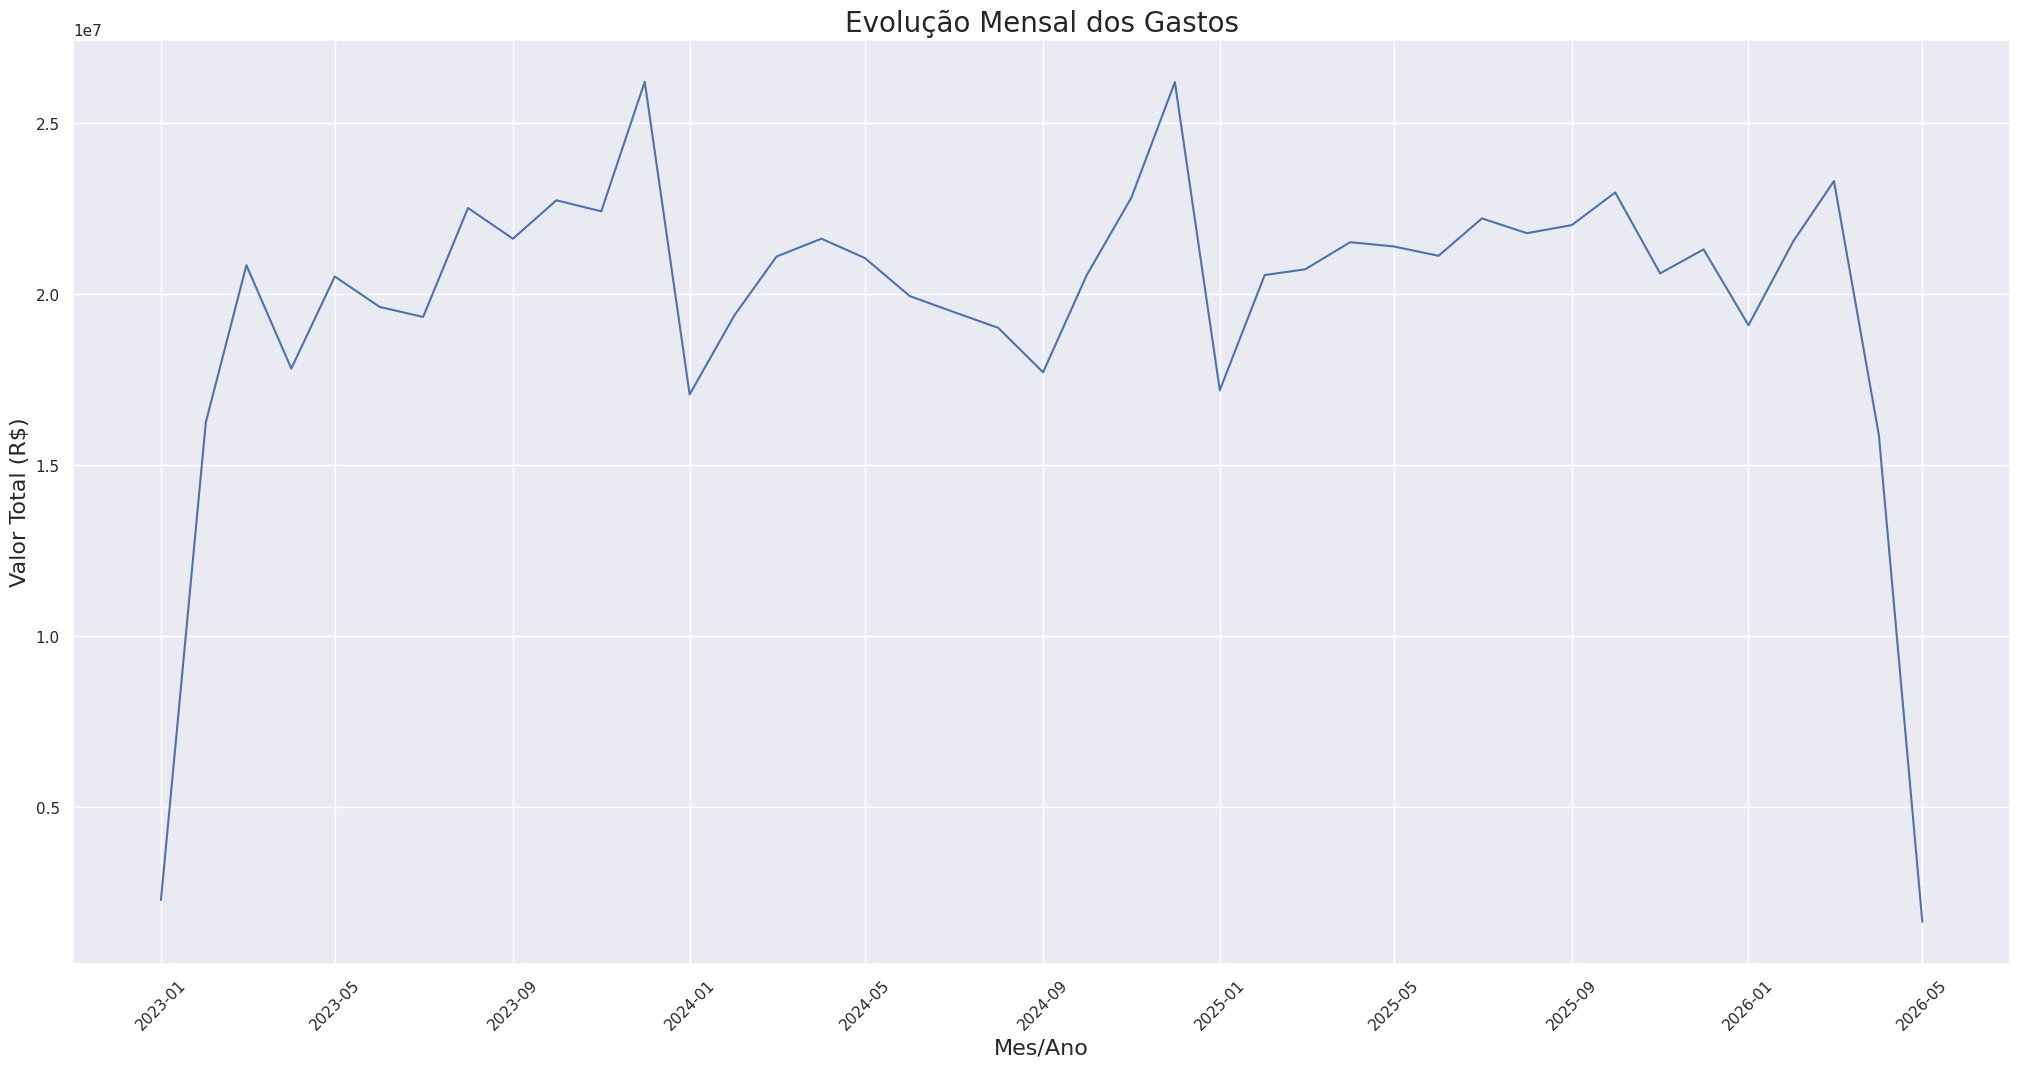

In [46]:
# evolução mensal
aux4_mes = df4.groupby(['ano', 'mes'])['valor_liquido'].sum().reset_index()
aux4_mes['ano_mes'] = pd.to_datetime({
    'year' : aux4_mes['ano'],
    'month': aux4_mes['mes'],
    'day'  : 1
})

sns.lineplot(x='ano_mes', y='valor_liquido', data=aux4_mes)
plt.title('Evolução Mensal dos Gastos', fontsize=20)
plt.xlabel('Mes/Ano', size=16)
plt.ylabel('Valor Total (R$)', size=16)
plt.xticks(rotation=45);

##### **H5 - Poucos fornecedores concentram a maior parte dos valores recebidos.**
Resposta: Sim. Os top 20 fornecedores demonstram 21,2% do total
gasto. TAM lidera com R$52M, seguida por GOL R$29M e AZUL R$18M. As três
companhias aéreas juntas dominam a categoria de passagens, evidenciando alta
concentração no mercado fornecedor parlamentar.

Top 20 fornecedores representam 21.2% do total gasto


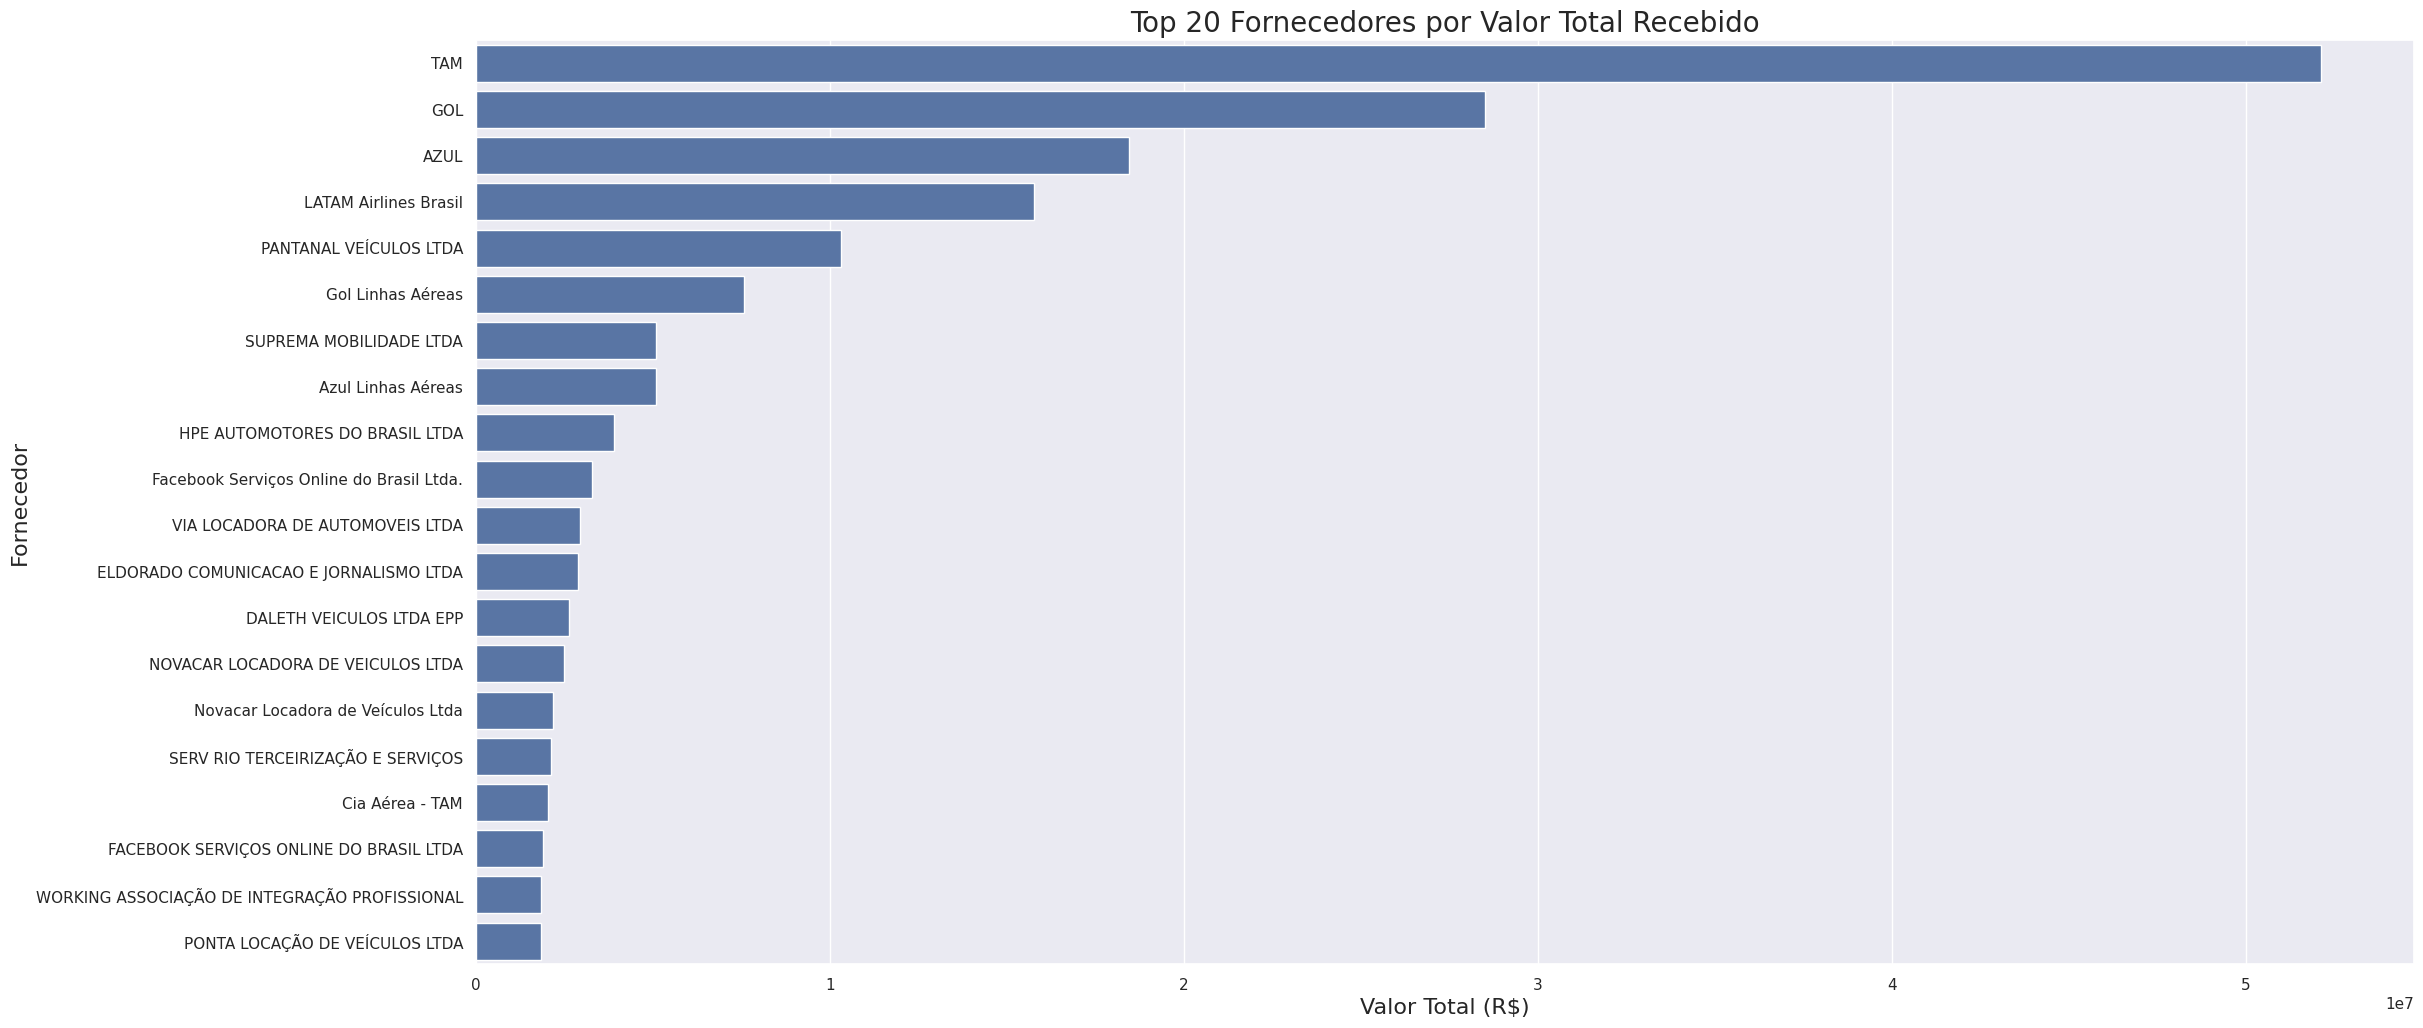

In [47]:
aux5 = df4.groupby('nome_fornecedor')['valor_liquido'].sum().reset_index().sort_values('valor_liquido', ascending=False)
aux5['perc_acumulado'] = (aux5['valor_liquido'].cumsum() / aux5['valor_liquido'].sum() * 100)

top20 = aux5.head(20)
print('Top 20 fornecedores representam {:.1f}% do total gasto'.format(
    top20['valor_liquido'].sum() / df4['valor_liquido'].sum() * 100))

sns.barplot(x='valor_liquido', y='nome_fornecedor', data=top20)
plt.title('Top 20 Fornecedores por Valor Total Recebido', fontsize=20)
plt.xlabel('Valor Total (R$)', size=16)
plt.ylabel('Fornecedor', size=16);

##### **H6 - Existe um pequeno grupo de despesas com valores muito acima da mediana da categoria, que podem indicar superfaturamento.**
Resposta: Sim. Foram identificados
17.391 registros outliers pelo método IQR (Q3 + 3×IQR), representando 2,71% do
total. A categoria com maior quantidade de outliers é Combustíveis e
Lubrificantes com 7.067
casos e valor máximo de
R$9.392. Divulgação da Atividade Parlamentar foi o maior valor máximo da base: R$184.428 em uma única despesa,
com valor médio dos outliers de R$41.230. Locação de Aeronaves tem o maior
valor médio de outliers: R$76.855, com máximo de R$104.258.

In [78]:
# cálculo dos quartis por categoria
q1 = df4.groupby('tipo_despesa')['valor_liquido'].transform(
    lambda x: x.quantile(0.25)
)

q3 = df4.groupby('tipo_despesa')['valor_liquido'].transform(
    lambda x: x.quantile(0.75)
)

iqr = q3 - q1

limite_iqr = q3 + (3 * iqr)

outliers_iqr = df4[
    df4['valor_liquido'] > limite_iqr
].copy()

outliers_iqr['limite_iqr'] = limite_iqr[
    df4['valor_liquido'] > limite_iqr
]

total_outliers = len(outliers_iqr)

pct_outliers = (
    total_outliers
    /
    len(df4)
    * 100
)

print(f"Total de registros outliers: {total_outliers:,}")
print(f"Percentual sobre o total   : {pct_outliers:.2f}%")

Total de registros outliers: 17,391
Percentual sobre o total   : 2.71%


In [49]:
outliers_iqr.groupby('tipo_despesa')['valor_liquido'].agg(['count', 'mean', 'max']).sort_values('count', ascending=False)

,count,mean,max
tipo_despesa,,,
COMBUSTÍVEIS E LUBRIFICANTES.,7067,2961.443168,9392.00
"SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO",3834,461.528586,2700.00
MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR,3156,9482.579328,31799.40
DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,1286,41230.408554,184428.00
"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL.",1098,2605.317268,24508.80
TELEFONIA,518,1817.679324,3150.92
FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,233,314.234120,1732.50
PASSAGEM AÉREA - REEMBOLSO,60,18180.908833,42877.80
ASSINATURA DE PUBLICAÇÕES,55,1993.011091,5478.00


##### **H7 - A categoria de divulgação parlamentar apresenta maior dispersão de valores entre deputados do mesmo partido.**
Resposta: Sim. Divulgação da Atividade
Parlamentar apresentou
o maior desvio padrão entre todas as categorias com o valor de  R$343.631, seguida por Locação de
Aeronaves R$225.276 e Locação de Embarcações R$184.809. Na categoria de divulgação, PSC e
Republicanos lideram a dispersão entre partidos R$435.000 e R$422.000
respectivamente, o que indica
um comportamento muito heterogêneo, o uso da cota de divulgação é bastamte individualizado, sem padrão
claro dentro das bancadas.

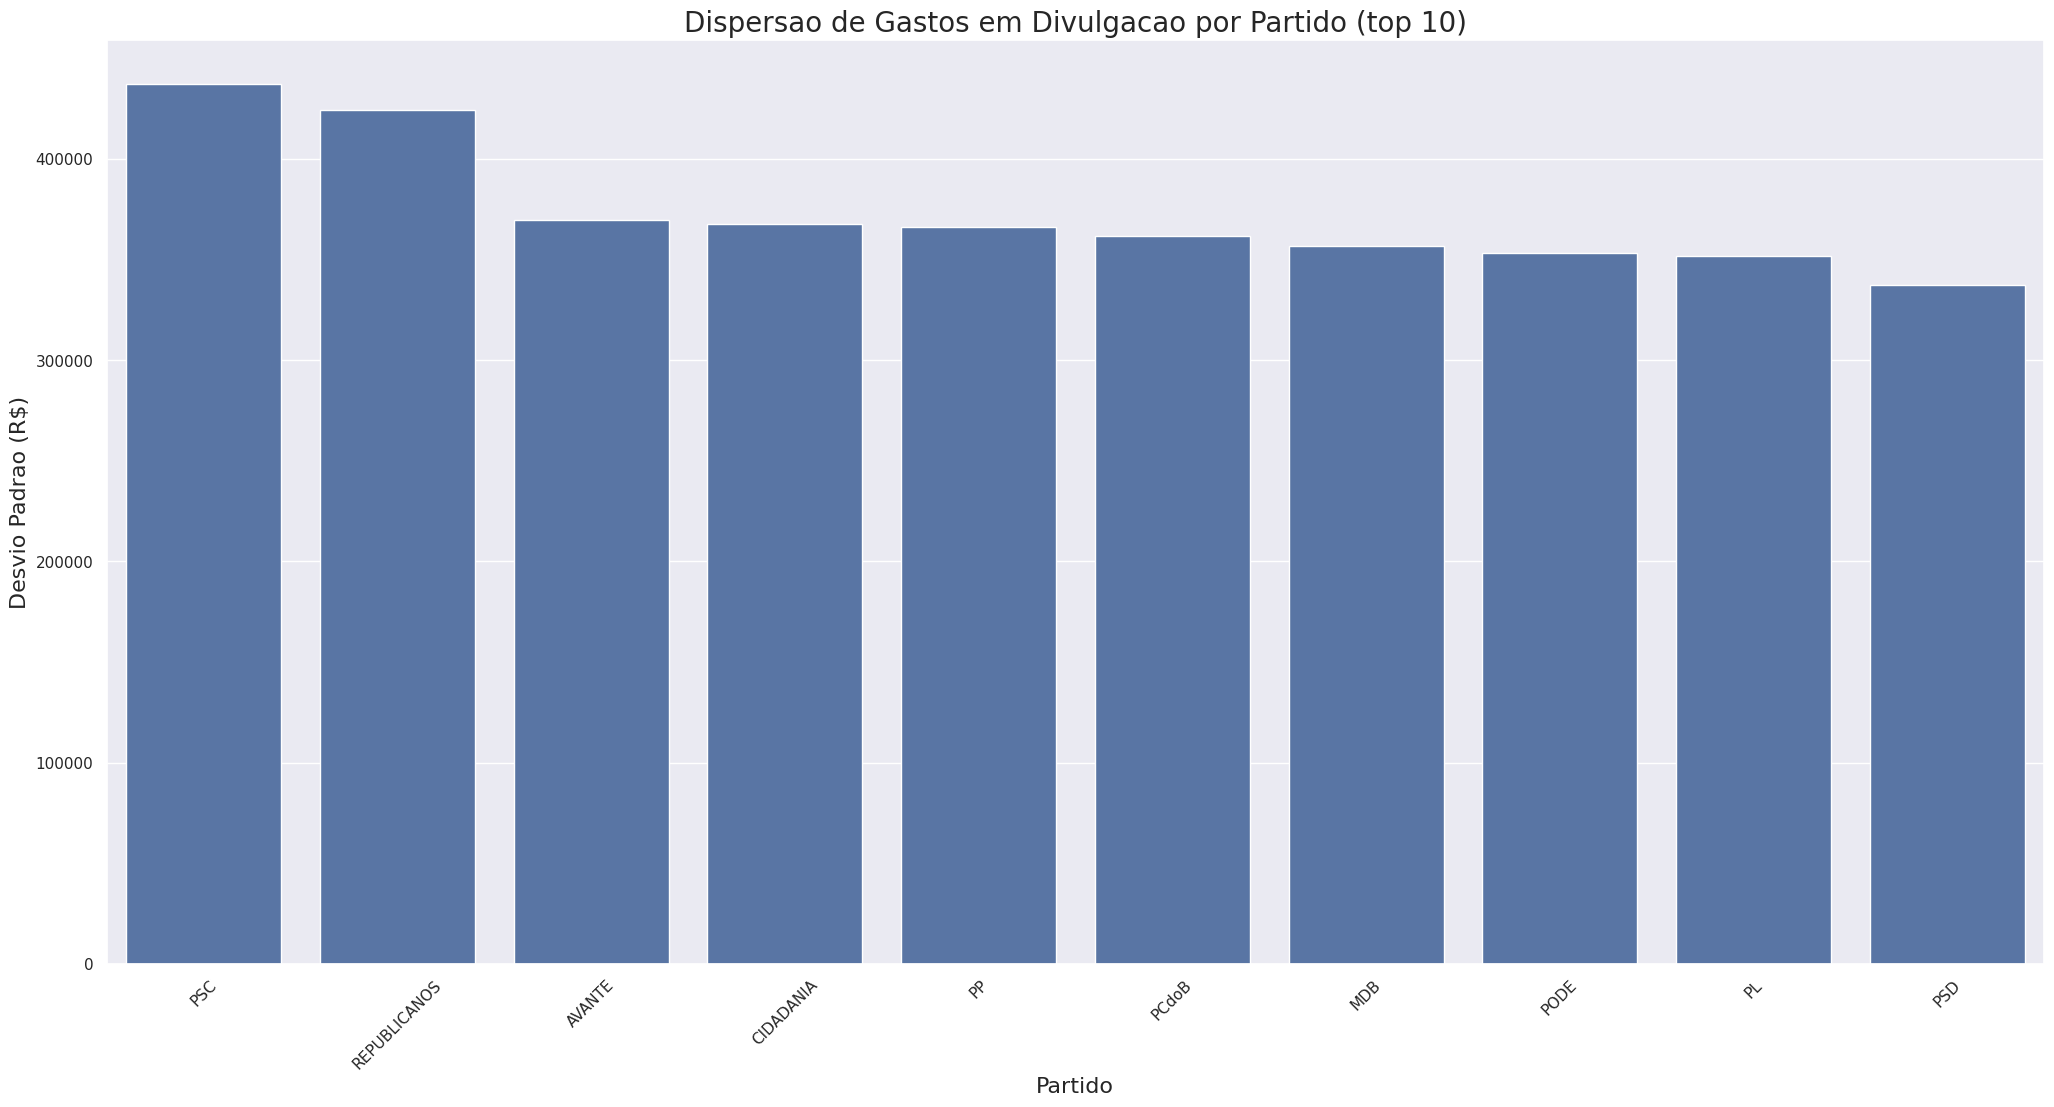

In [50]:
aux7 = df4[df4['tipo_despesa'].str.contains('DIVULGA', na=False)].copy()

aux7_std = (aux7.groupby(['partido', 'id_deputado'])['valor_liquido']
                .sum().reset_index()
                .groupby('partido')['valor_liquido']
                .std().reset_index())
aux7_std.columns = ['partido', 'desvio_padrao']
aux7_std = aux7_std.sort_values('desvio_padrao', ascending=False).head(10)

sns.barplot(x='partido', y='desvio_padrao', data=aux7_std)
plt.title('Dispersao de Gastos em Divulgacao por Partido (top 10)', fontsize=20)
plt.xlabel('Partido', size=16)
plt.ylabel('Desvio Padrao (R$)', size=16)
plt.xticks(rotation=45);

In [51]:
# comparando com outras categorias
aux7_comp = (df4.groupby(['tipo_despesa', 'id_deputado'])['valor_liquido']
                .sum().reset_index()
                .groupby('tipo_despesa')['valor_liquido']
                .std().reset_index())
aux7_comp.columns = ['tipo_despesa', 'desvio_padrao']
aux7_comp.sort_values('desvio_padrao', ascending=False)

,tipo_despesa,desvio_padrao
4,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,343631.158496
7,LOCAÇÃO OU FRETAMENTO DE AERONAVES,225276.567133
8,LOCAÇÃO OU FRETAMENTO DE EMBARCAÇÕES,184809.144395
10,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,169233.099143
9,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,151224.561112
14,PASSAGEM AÉREA - SIGEPA,149637.526375
2,COMBUSTÍVEIS E LUBRIFICANTES.,87251.418929
16,SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPE...,84286.578754
13,PASSAGEM AÉREA - RPA,32837.632645
6,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ...",30042.727264


## **4.3 Análise Multivariada**

**descrever a associação entre mais que duas variáveis**

### **4.3.1 Numerical Attributes**

In [52]:
df1_num.head()

,valor_documento,valor_liquido,valor_glosa,ano,mes
0,52.98,52.98,0.0,2023,9
1,67.30,67.30,0.0,2023,11
2,43.20,43.20,0.0,2023,5
3,43.20,43.20,0.0,2023,6
4,43.20,43.20,0.0,2023,7


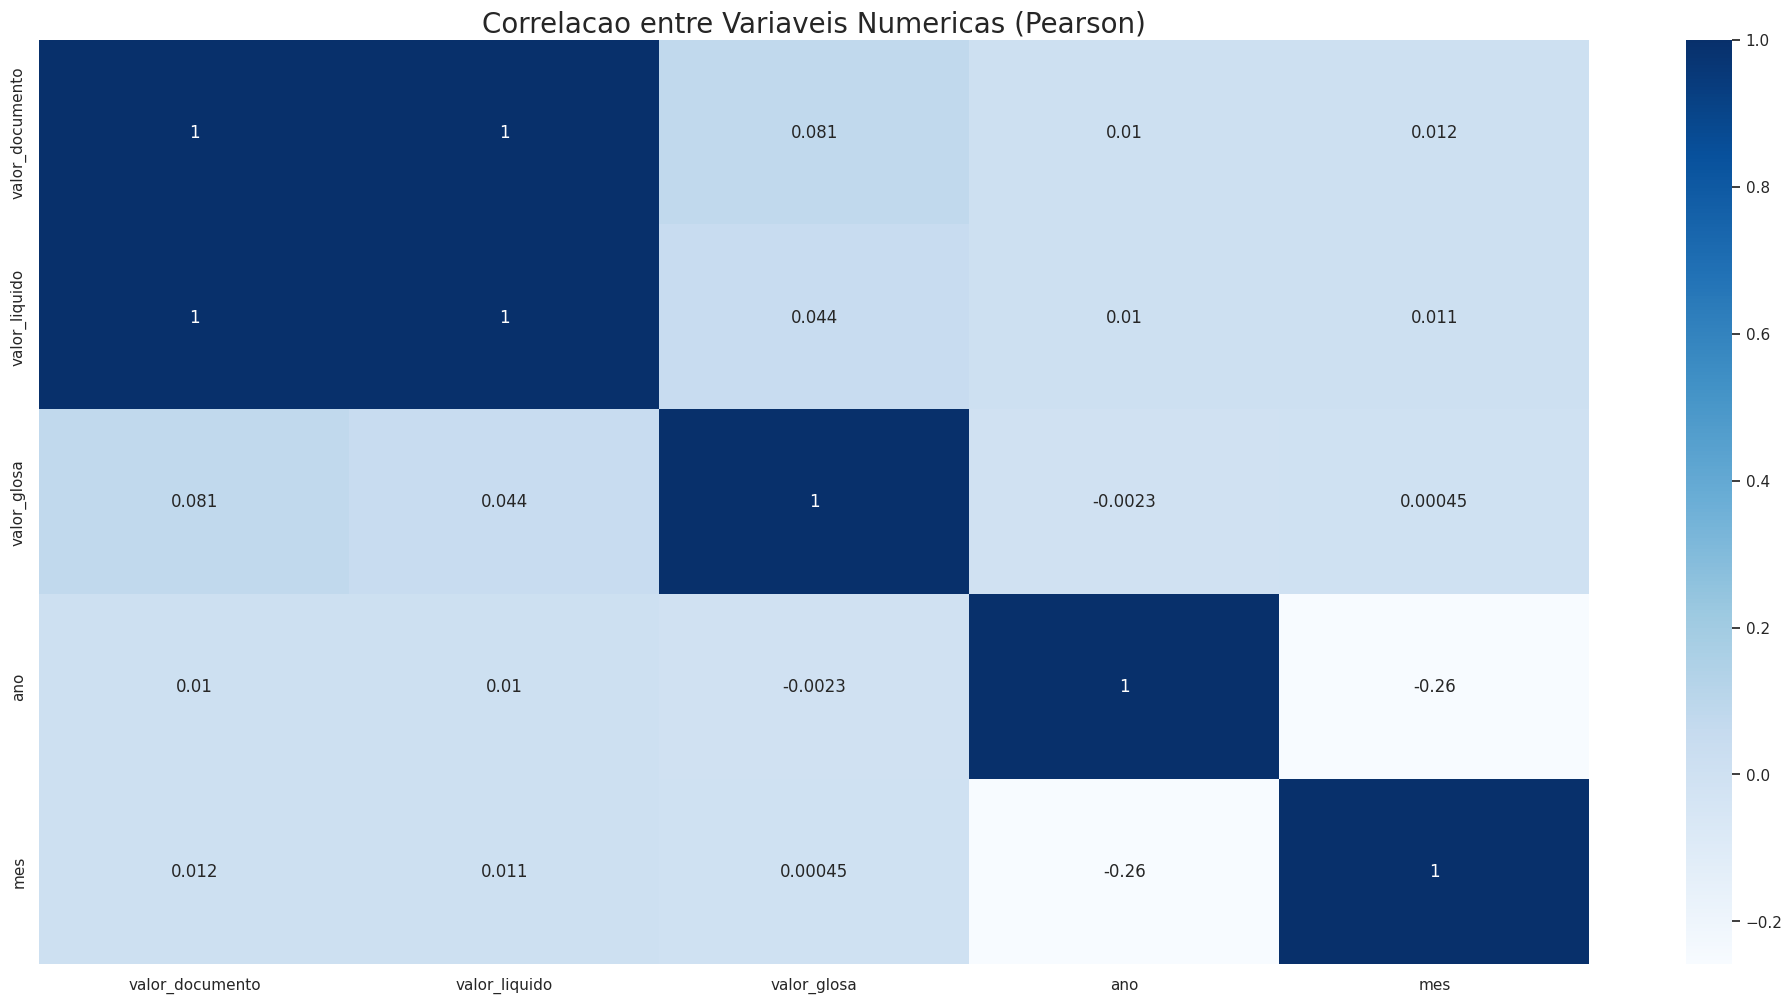

In [53]:
correlation = df1_num.corr(method='pearson')
sns.heatmap(correlation, annot=True, cmap='Blues')
plt.title('Correlacao entre Variaveis Numericas (Pearson)', fontsize=20);

### **4.3.2 Categorical Attributes**

In [54]:
df1_cat.head()

,id_deputado,tipo_despesa,cod_documento,nome_fornecedor,cnpj_cpf_fornecedor,num_documento,url_documento,nome,partido,uf
0,220593,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7610066,3XIS COMERCIO VAREJISTA E ATACADISTA DE PAPELA...,42999796000188.0,35537,http://www.camara.leg.br/cota-parlamentar/nota...,Abilio Brunini,PL,MT
1,220593,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7657491,AGUAS CUIABA S.A,14995581000153.0,01,https://www.camara.leg.br/cota-parlamentar/doc...,Abilio Brunini,PL,MT
2,220593,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7552621,AGUAS CUIABA S.A,14995581000153.0,11533052023001,https://www.camara.leg.br/cota-parlamentar/doc...,Abilio Brunini,PL,MT
3,220593,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7587236,AGUAS CUIABA S.A,14995581000153.0,11533062023001,https://www.camara.leg.br/cota-parlamentar/doc...,Abilio Brunini,PL,MT
4,220593,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7587239,AGUAS CUIABA S.A,14995581000153.0,11533072023001,https://www.camara.leg.br/cota-parlamentar/doc...,Abilio Brunini,PL,MT


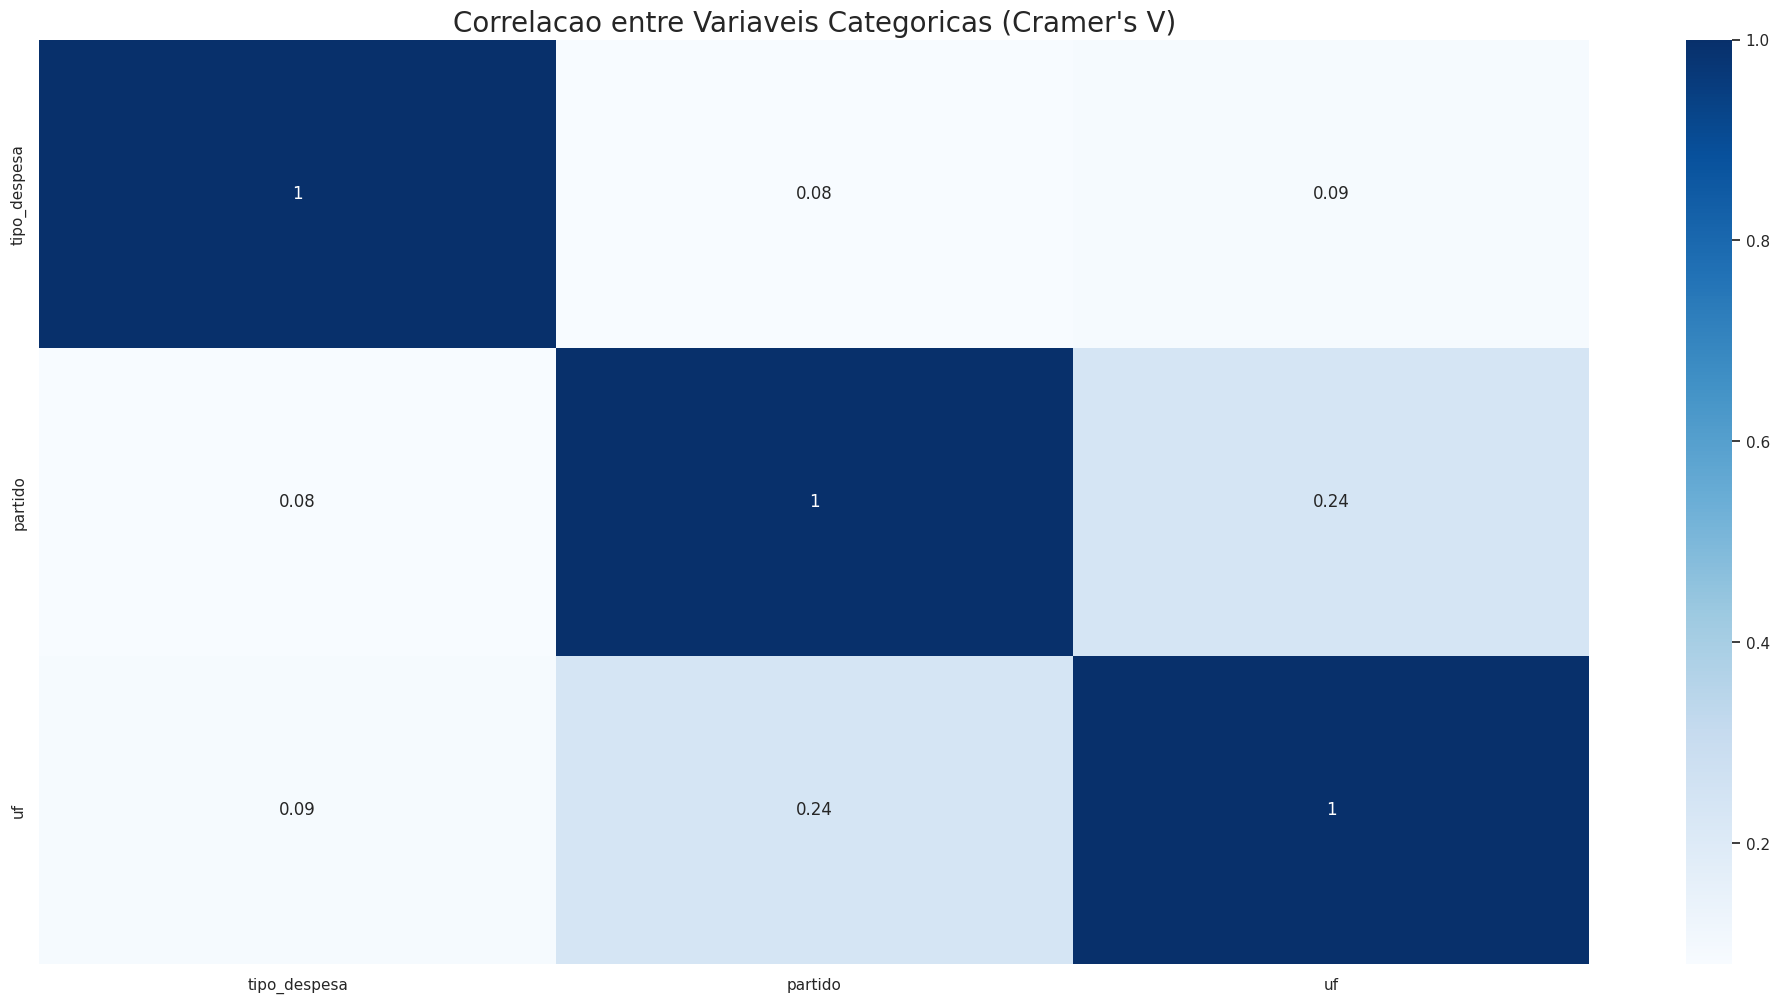

In [55]:
a = df4[['tipo_despesa', 'partido', 'uf']].copy()
rows = []

for var1 in a:
    col = []
    for var2 in a:
        cramers = cramer_v(a[var1], a[var2])
        col.append(round(cramers, 2))
    rows.append(col)

cramers_results = np.array(rows)
dfcv = pd.DataFrame(cramers_results, columns=a.columns, index=a.columns)
sns.heatmap(dfcv, cmap='Blues', annot=True)
plt.title("Correlacao entre Variaveis Categoricas (Cramer's V)", fontsize=20);

---
# **5.0 Data Preparation**

In [56]:
df5 = df4.copy()

## **5.1 Feature Engineering para o Modelo**

Variáveis derivadas para capturar o comportamento de cada despesa dentro da sua categoria:

• `mediana_categoria`: mediana do valor líquido por categoria

• `razao_mediana`: razão entre o valor da despesa e a mediana da categoria — quanto maior, mais discrepante

• `z_score_categoria`: z-score do valor dentro da categoria

In [57]:
stats_cat = df5.groupby('tipo_despesa')['valor_liquido'].agg(
    mediana_categoria='median',
    media_categoria='mean',
    desvio_categoria='std'
).reset_index()

df5 = df5.merge(stats_cat, on='tipo_despesa', how='left')

df5['razao_mediana']    = df5['valor_liquido'] / (df5['mediana_categoria'] + 1)
df5['z_score_categoria'] = df5.groupby('tipo_despesa')['valor_liquido'].transform(
    lambda x: zscore(x, ddof=1)
)

df5.sample(3)

,id_deputado,ano,mes,tipo_despesa,cod_documento,data_documento,valor_documento,valor_liquido,valor_glosa,nome_fornecedor,cnpj_cpf_fornecedor,num_documento,url_documento,nome,partido,uf,year,month,day,mediana_categoria,media_categoria,desvio_categoria,razao_mediana,z_score_categoria
278589,160673,2025,8,COMBUSTÍVEIS E LUBRIFICANTES.,7976912,2025-08-11 10:37:23,150.0,150.0,0.0,MP POSTOS E LOGISTICA LTDA NAOMETOQUE FILIAL 12,23448964001336.0,764559,http://www.camara.leg.br/cota-parlamentar/nota...,Giovani Cherini,PL,RS,2025,8,11,221.145,307.038310,606.987904,0.675235,-0.258717
357455,204574,2024,11,PASSAGEM AÉREA - SIGEPA,291664,2024-11-21 12:00:00,80.0,80.0,0.0,TAM,NAO INFORMADO,9572208284807,NAO INFORMADO,Junior Lourenço,PL,MA,2024,11,21,1366.370,1185.425398,759.482344,0.058506,-1.455498
625011,178992,2025,4,"SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO",7892052,2025-04-01 00:00:00,60.0,60.0,0.0,SINPETAXI,31708000100.0,4376,https://www.camara.leg.br/cota-parlamentar/doc...,Vitor Lippi,PSDB,SP,2025,4,1,21.390,53.205475,136.062858,2.679768,0.049937


## **5.2 Rescaling**

RobustScaler — mais resistente a outliers, adequado para este problema.

In [58]:
le_tipo    = LabelEncoder()
le_partido = LabelEncoder()
le_uf      = LabelEncoder()

df5['tipo_despesa_enc'] = le_tipo.fit_transform(df5['tipo_despesa'])
df5['partido_enc']      = le_partido.fit_transform(df5['partido'])
df5['uf_enc']           = le_uf.fit_transform(df5['uf'])

features = [
    'valor_liquido',
    'valor_glosa',
    'mediana_categoria',
    'razao_mediana',
    'z_score_categoria',
    'tipo_despesa_enc',
    'partido_enc',
    'uf_enc',
    'year',
    'month'
]

scaler = RobustScaler()
X = scaler.fit_transform(df5[features])

print('Shape das features para o modelo: {}'.format(X.shape))

Shape das features para o modelo: (642269, 10)


## **5.3 Encoder**

Label Encoding aplicado nas variáveis categóricas `tipo_despesa`, `partido` e `uf` para viabilizar o uso no Isolation Forest, que trabalha apenas com valores numéricos.

---
# **6.0 Feature Selection**

In [59]:
df6 = df5.copy()

## **6.1 Features Selecionadas**

As features foram escolhidas com base na relevância para identificação de despesas discrepantes:

• `valor_liquido` — valor central da análise

• `valor_glosa` — valor não reembolsado, pode indicar irregularidade

• `mediana_categoria` e `razao_mediana` — capturam desvio em relação ao padrão da categoria

• `z_score_categoria` — padroniza o desvio dentro da categoria

• `tipo_despesa_enc`, `partido_enc`, `uf_enc` — contexto da despesa

• `year`, `month` — sazonalidade

In [60]:
print('Features utilizadas no modelo:')
for f in features:
    print('  -', f)

Features utilizadas no modelo:
  - valor_liquido
  - valor_glosa
  - mediana_categoria
  - razao_mediana
  - z_score_categoria
  - tipo_despesa_enc
  - partido_enc
  - uf_enc
  - year
  - month


---
# **7.0 Machine Learning**

In [61]:
df7 = df6.copy()

## **7.1 Técnica Escolhida: Isolation Forest**

**Por que Isolation Forest?**

O Isolation Forest é um algoritmo baseado em árvores de decisão que isola observações ao invés de modelar o comportamento normal. A ideia central é que anomalias são mais fáceis de isolar — precisam de menos partições para serem separadas.

Ele se encaixa neste problema porque:

• Não assume distribuição normal dos dados (os gastos têm distribuição altamente assimétrica)

• Funciona bem com alta dimensionalidade

• É eficiente para bases grandes (~650 mil registros)

• Não exige rótulos — não temos uma lista prévia de gastos fraudulentos

**Pergunta que o modelo responde:** existem despesas com valores tão distantes do padrão da categoria que podem indicar superfaturamento ou incompatibilidade com o objeto declarado?

**Parâmetro `contamination`:** define a proporção esperada de anomalias. Usaremos 0.05 (5%), razoável para este domínio.

In [62]:
model_if = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

print('Treinando o modelo...')
model_if.fit(X)

df7['anomalia']       = model_if.predict(X)
df7['anomaly_score']  = model_if.decision_function(X)
df7['anomalia_label'] = df7['anomalia'].map({1: 'Normal', -1: 'Anomalia'})

print('Treinamento concluido!')
print('\nDistribuicao das predicoes:')
print(df7['anomalia_label'].value_counts())
print('\nPercentual de anomalias: {:.2f}%'.format(
    (df7['anomalia'] == -1).sum() / len(df7) * 100))

Treinando o modelo...
Treinamento concluido!

Distribuicao das predicoes:
anomalia_label
Normal      610155
Anomalia     32114
Name: count, dtype: int64

Percentual de anomalias: 5.00%


---
# **8.0 Model Performance**

In [63]:
df8 = df7.copy()

## **8.1 Distribuição do Anomaly Score**

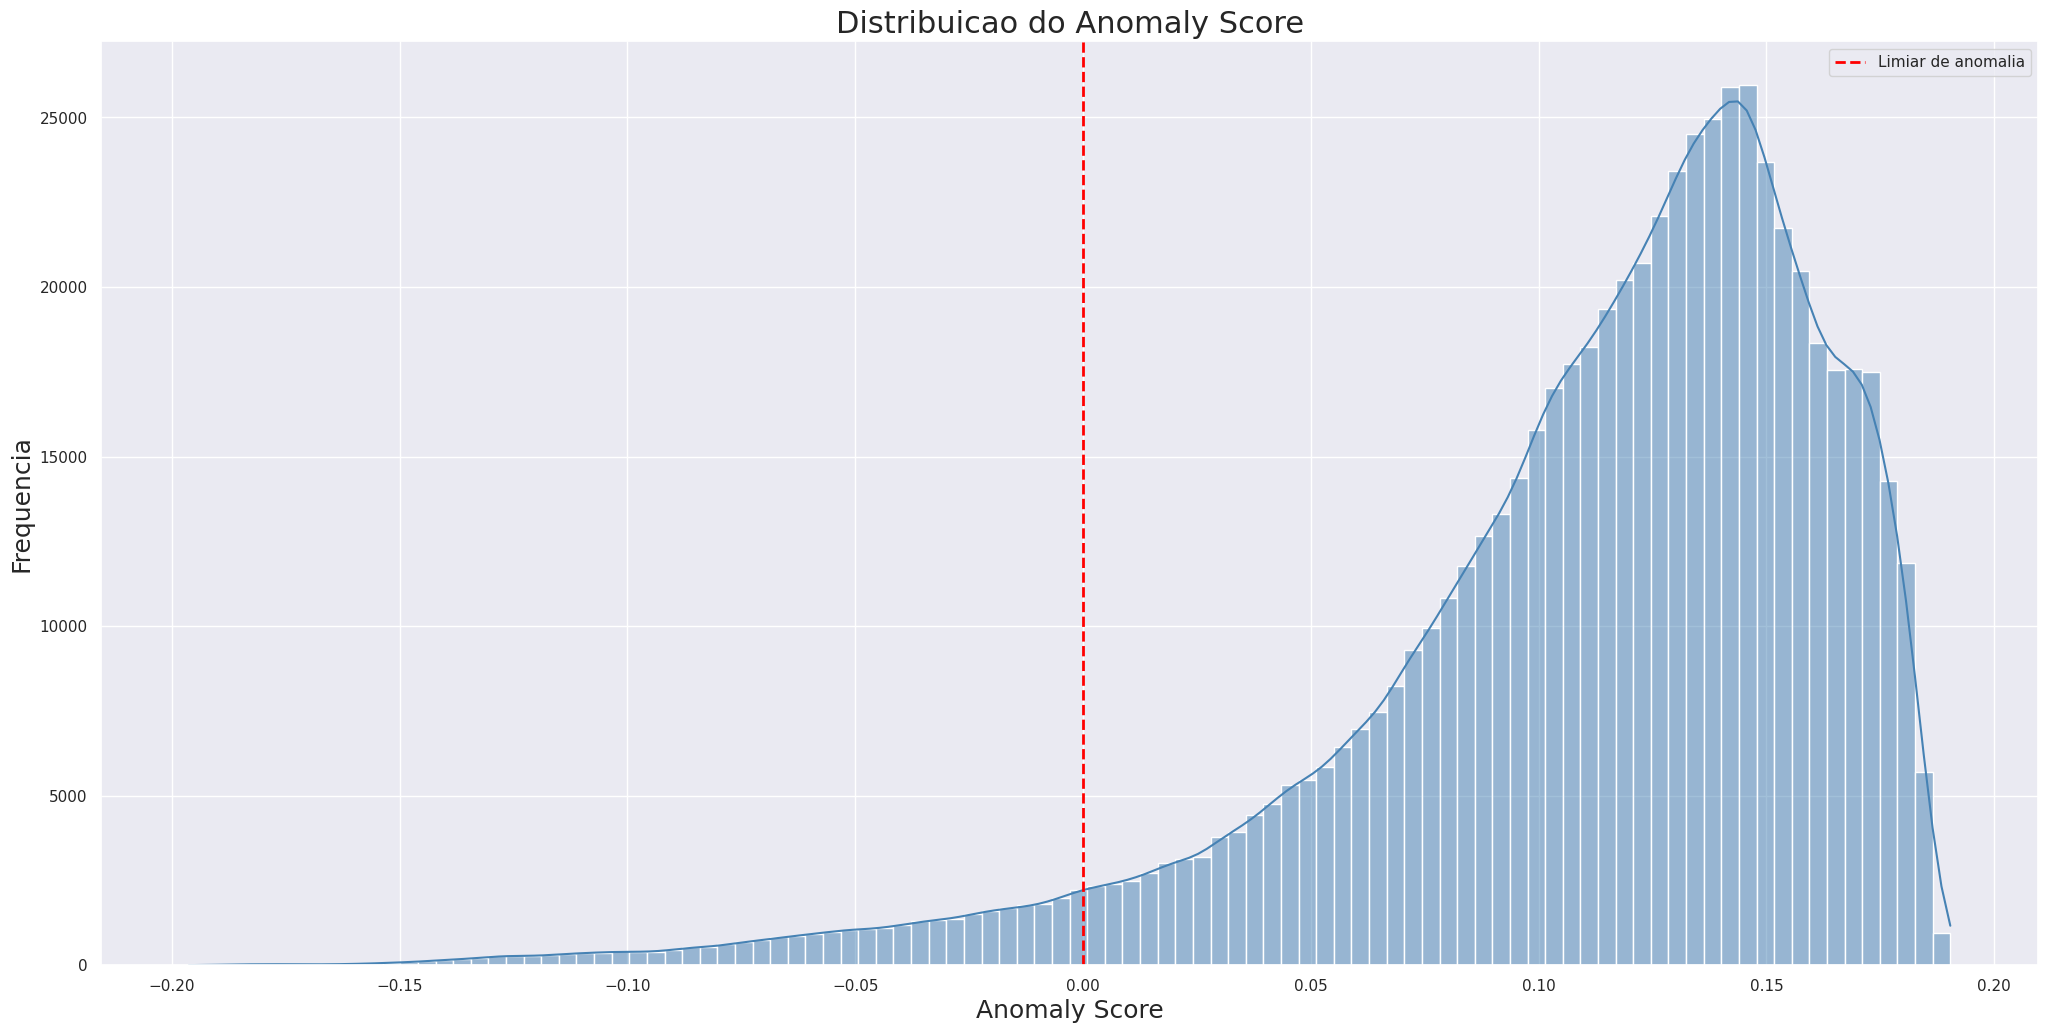

In [64]:
sns.histplot(df8['anomaly_score'], bins=100, kde=True, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Limiar de anomalia')
plt.title('Distribuicao do Anomaly Score', fontsize=22)
plt.xlabel('Anomaly Score', size=18)
plt.ylabel('Frequencia', size=18)
plt.legend();

## **8.2 Anomalias por Categoria**

In [65]:
anomalias = df8[df8['anomalia'] == -1].copy()

por_categoria = (anomalias.groupby('tipo_despesa')
                           .agg(qtd=('valor_liquido', 'count'),
                                valor_total=('valor_liquido', 'sum'),
                                valor_medio=('valor_liquido', 'mean'),
                                valor_max=('valor_liquido', 'max'))
                           .sort_values('qtd', ascending=False)
                           .reset_index())
por_categoria

,tipo_despesa,qtd,valor_total,valor_medio,valor_max
0,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,9678,1.838796e+08,18999.749971,184428.00
1,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,6798,5.553559e+07,8169.401328,18970.40
2,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,5122,3.908357e+07,7630.528344,31799.40
3,COMBUSTÍVEIS E LUBRIFICANTES.,3914,1.668079e+07,4261.827971,9392.00
4,"SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO",2460,1.506681e+06,612.471927,2700.00
5,TELEFONIA,2406,2.068428e+06,859.695869,3150.92
6,SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPE...,478,3.892369e+06,8143.031464,8700.00
7,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ...",362,1.464234e+06,4044.845110,24508.80
8,LOCAÇÃO OU FRETAMENTO DE AERONAVES,304,7.145129e+06,23503.714836,104258.00
9,PASSAGEM AÉREA - SIGEPA,209,7.477095e+05,3577.557416,6826.20


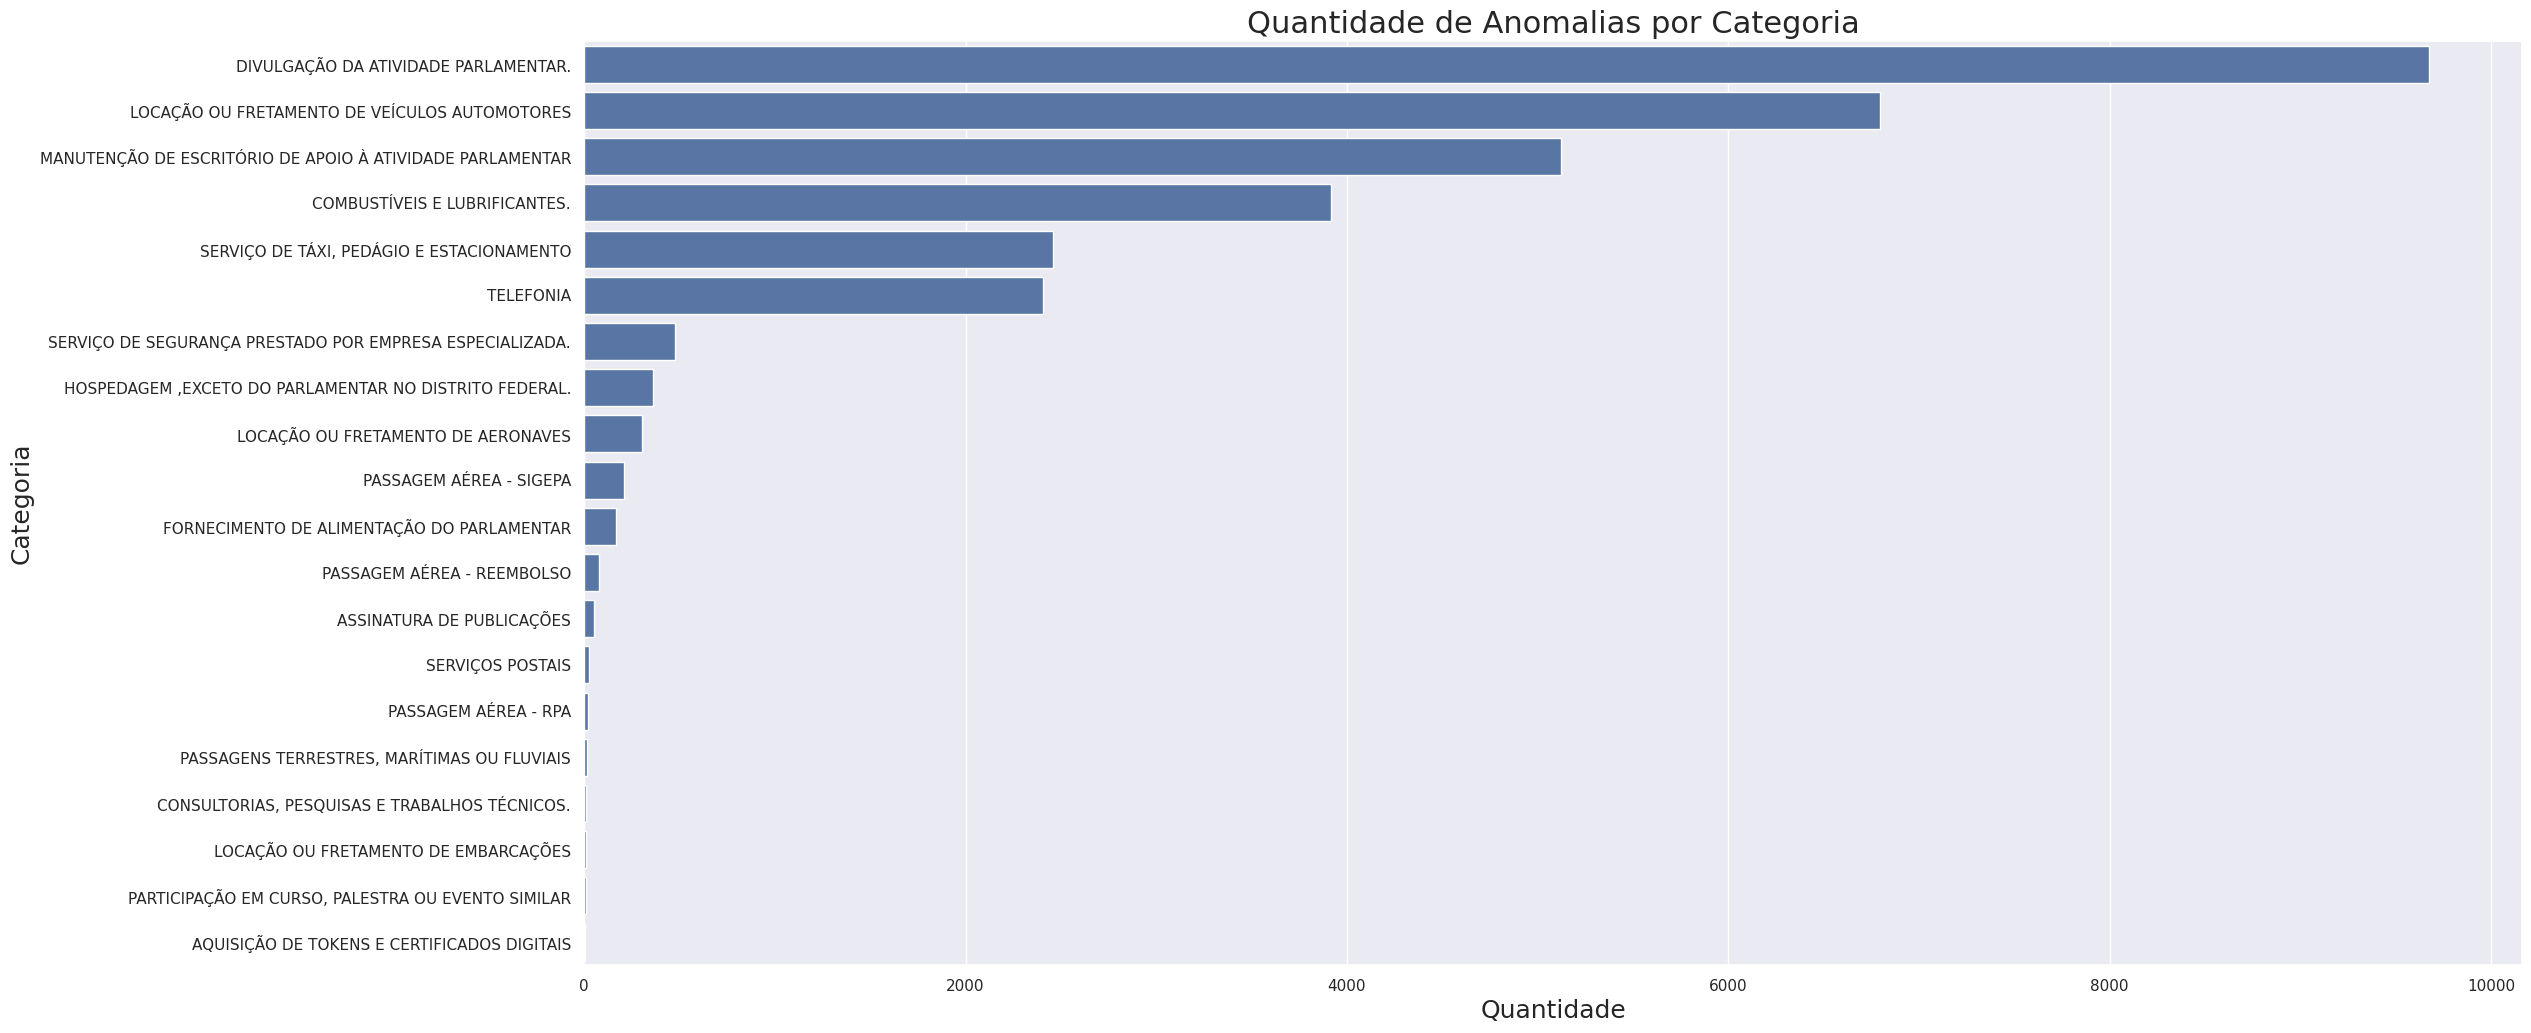

In [66]:
sns.barplot(x='qtd', y='tipo_despesa', data=por_categoria)
plt.title('Quantidade de Anomalias por Categoria', fontsize=22)
plt.xlabel('Quantidade', size=18)
plt.ylabel('Categoria', size=18);

## **8.3 Comparação: Normal vs Anomalia**

In [67]:
comparativo = df8.groupby('anomalia_label')['valor_liquido'].agg(['count', 'mean', 'median', 'max']).reset_index()
comparativo.columns = ['Classificacao', 'Quantidade', 'Media (R$)', 'Mediana (R$)', 'Maximo (R$)']
comparativo

,Classificacao,Quantidade,Media (R$),Mediana (R$),Maximo (R$)
0,Anomalia,32114,9771.313814,8000.0,184428.0
1,Normal,610155,818.723740,250.0,14171.5


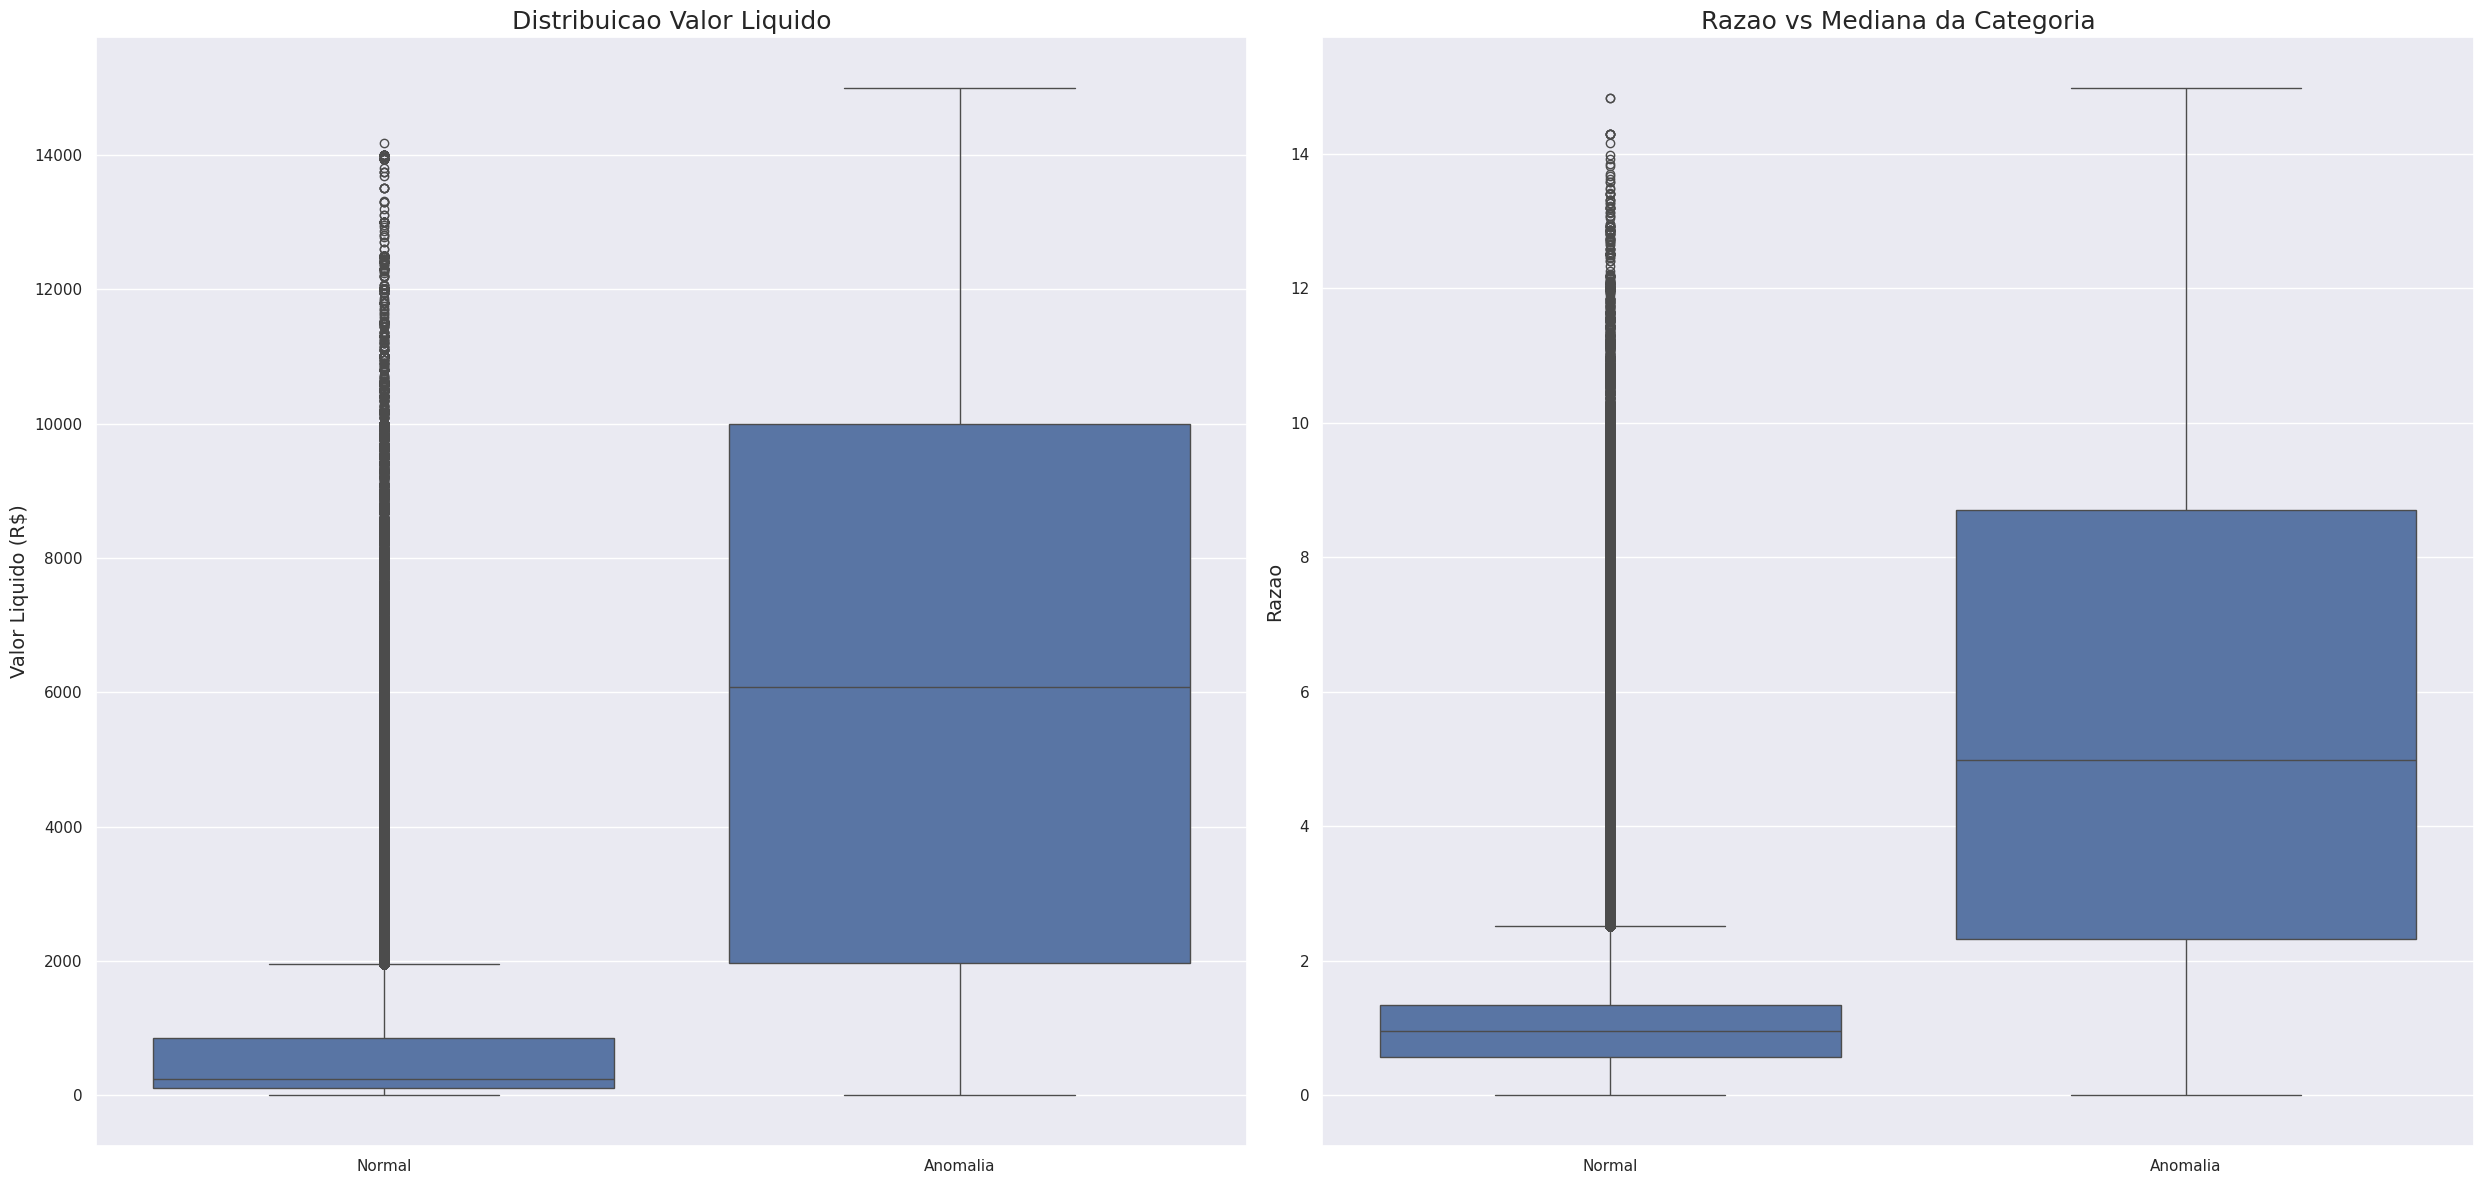

In [68]:
plt.subplot(1, 2, 1)
sns.boxplot(x='anomalia_label', y='valor_liquido',
            data=df8[df8['valor_liquido'] < df8['valor_liquido'].quantile(0.99)])
plt.title('Distribuicao Valor Liquido', fontsize=18)
plt.xlabel('')
plt.ylabel('Valor Liquido (R$)', size=14)

plt.subplot(1, 2, 2)
sns.boxplot(x='anomalia_label', y='razao_mediana',
            data=df8[df8['razao_mediana'] < df8['razao_mediana'].quantile(0.99)])
plt.title('Razao vs Mediana da Categoria', fontsize=18)
plt.xlabel('')
plt.ylabel('Razao', size=14)

plt.tight_layout();

## **8.4 Top Anomalias — Maiores Valores**

In [69]:
top_anomalias = (anomalias[['tipo_despesa', 'partido', 'uf',
                              'nome_fornecedor', 'valor_liquido',
                              'mediana_categoria', 'razao_mediana', 'anomaly_score']]
                .sort_values('valor_liquido', ascending=False)
                .head(20)
                .reset_index(drop=True))
top_anomalias

,tipo_despesa,partido,uf,nome_fornecedor,valor_liquido,mediana_categoria,razao_mediana,anomaly_score
0,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,MDB,RR,CESAR V. M. SANTANA EIRELI-ME,184428.0,3000.0,61.455515,-0.182227
1,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,REPUBLICANOS,SE,Austregesilo Junior Aragão Melo,164900.0,3000.0,54.948351,-0.187448
2,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,REPUBLICANOS,TO,GRÁFICA E EDITORA WR-EIRELI-ME,163791.0,3000.0,54.578807,-0.192146
3,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,PL,GO,Poligrafica Industria e Comercio Ltda,150960.0,3000.0,50.303232,-0.178454
4,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,PL,RN,Maricleydson Costa da Silva,149000.0,3000.0,49.650117,-0.186280
5,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,PSB,PE,STAMPA DIGITAL & MIDIA EXTERIOR LTDA,148500.0,3000.0,49.483505,-0.173464
6,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,UNIÃO,BA,ELMARA ROCHA DOS SANTOS NUNES LTDA,140000.0,3000.0,46.651116,-0.188073
7,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,PSC,MA,Adriano L Silva Engenharia Serviços e Comércio,140000.0,3000.0,46.651116,-0.178921
8,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,REPUBLICANOS,AM,AMR COMERCIO DE ARTIGOS DE ESCRITÓRIOS E SERVI...,130000.0,3000.0,43.318894,-0.179046
9,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,PSC,MA,Adriano L Silva Engenharia Serviços e Comércio,130000.0,3000.0,43.318894,-0.181043


## **8.5 Análise de Sensibilidade**

Testando diferentes valores de `contamination` para verificar a robustez do modelo:

In [70]:
resultados = []

for cont in [0.01, 0.03, 0.05, 0.07, 0.10]:
    m = IsolationForest(n_estimators=100, contamination=cont, random_state=42, n_jobs=-1)
    pred = m.fit_predict(X)
    n_anomalias = (pred == -1).sum()
    resultados.append({
        'contamination': cont,
        'anomalias_detectadas': n_anomalias,
        'percentual': round(n_anomalias / len(X) * 100, 2),
        'valor_medio_anomalias': round(df5.loc[pred == -1, 'valor_liquido'].mean(), 2)
    })

pd.DataFrame(resultados)

,contamination,anomalias_detectadas,percentual,valor_medio_anomalias
0,0.01,6423,1.0,16401.77
1,0.03,19269,3.0,11946.42
2,0.05,32114,5.0,9771.31
3,0.07,44959,7.0,8370.21
4,0.10,64227,10.0,6973.53


---
# **9.0 Traducao e Interpretacao do Erro**

In [71]:
df9 = df8.copy()

# **9.1 Business Performance**

In [72]:
valor_total_base      = df9['valor_liquido'].sum()
valor_anomalias       = anomalias['valor_liquido'].sum()
perc_financeiro       = valor_anomalias / valor_total_base * 100

print('Valor total da base (R$)             : {:,.2f}'.format(valor_total_base))
print('Valor total das anomalias (R$)       : {:,.2f}'.format(valor_anomalias))
print('Participacao financeira das anomalias: {:.2f}%'.format(perc_financeiro))

Valor total da base (R$)             : 813,344,355.20
Valor total das anomalias (R$)       : 313,795,971.82
Participacao financeira das anomalias: 38.58%


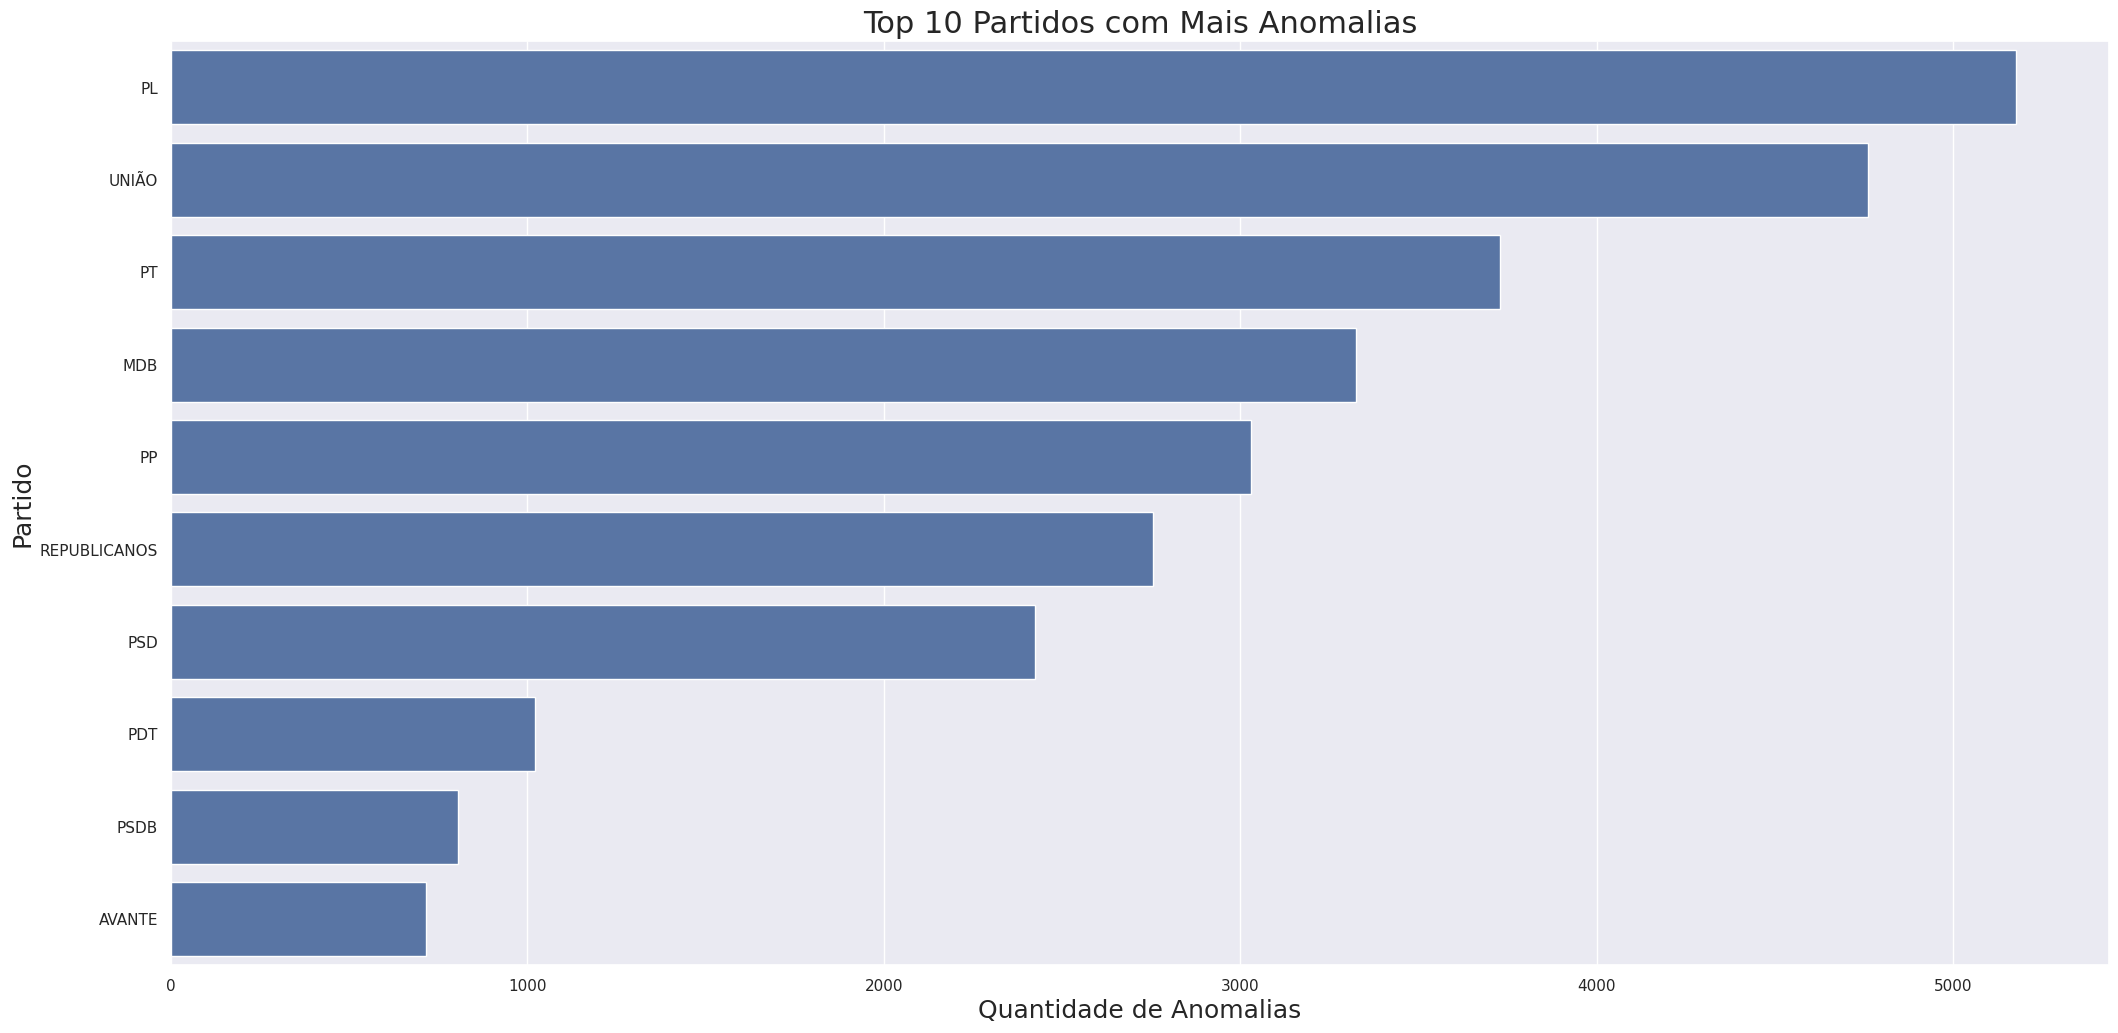

In [73]:
# anomalias por partido
por_partido = (anomalias.groupby('partido')
                         .agg(qtd=('valor_liquido', 'count'),
                              valor_medio=('valor_liquido', 'mean'))
                         .sort_values('qtd', ascending=False)
                         .head(10)
                         .reset_index())

sns.barplot(x='qtd', y='partido', data=por_partido)
plt.title('Top 10 Partidos com Mais Anomalias', fontsize=22)
plt.xlabel('Quantidade de Anomalias', size=18)
plt.ylabel('Partido', size=18);

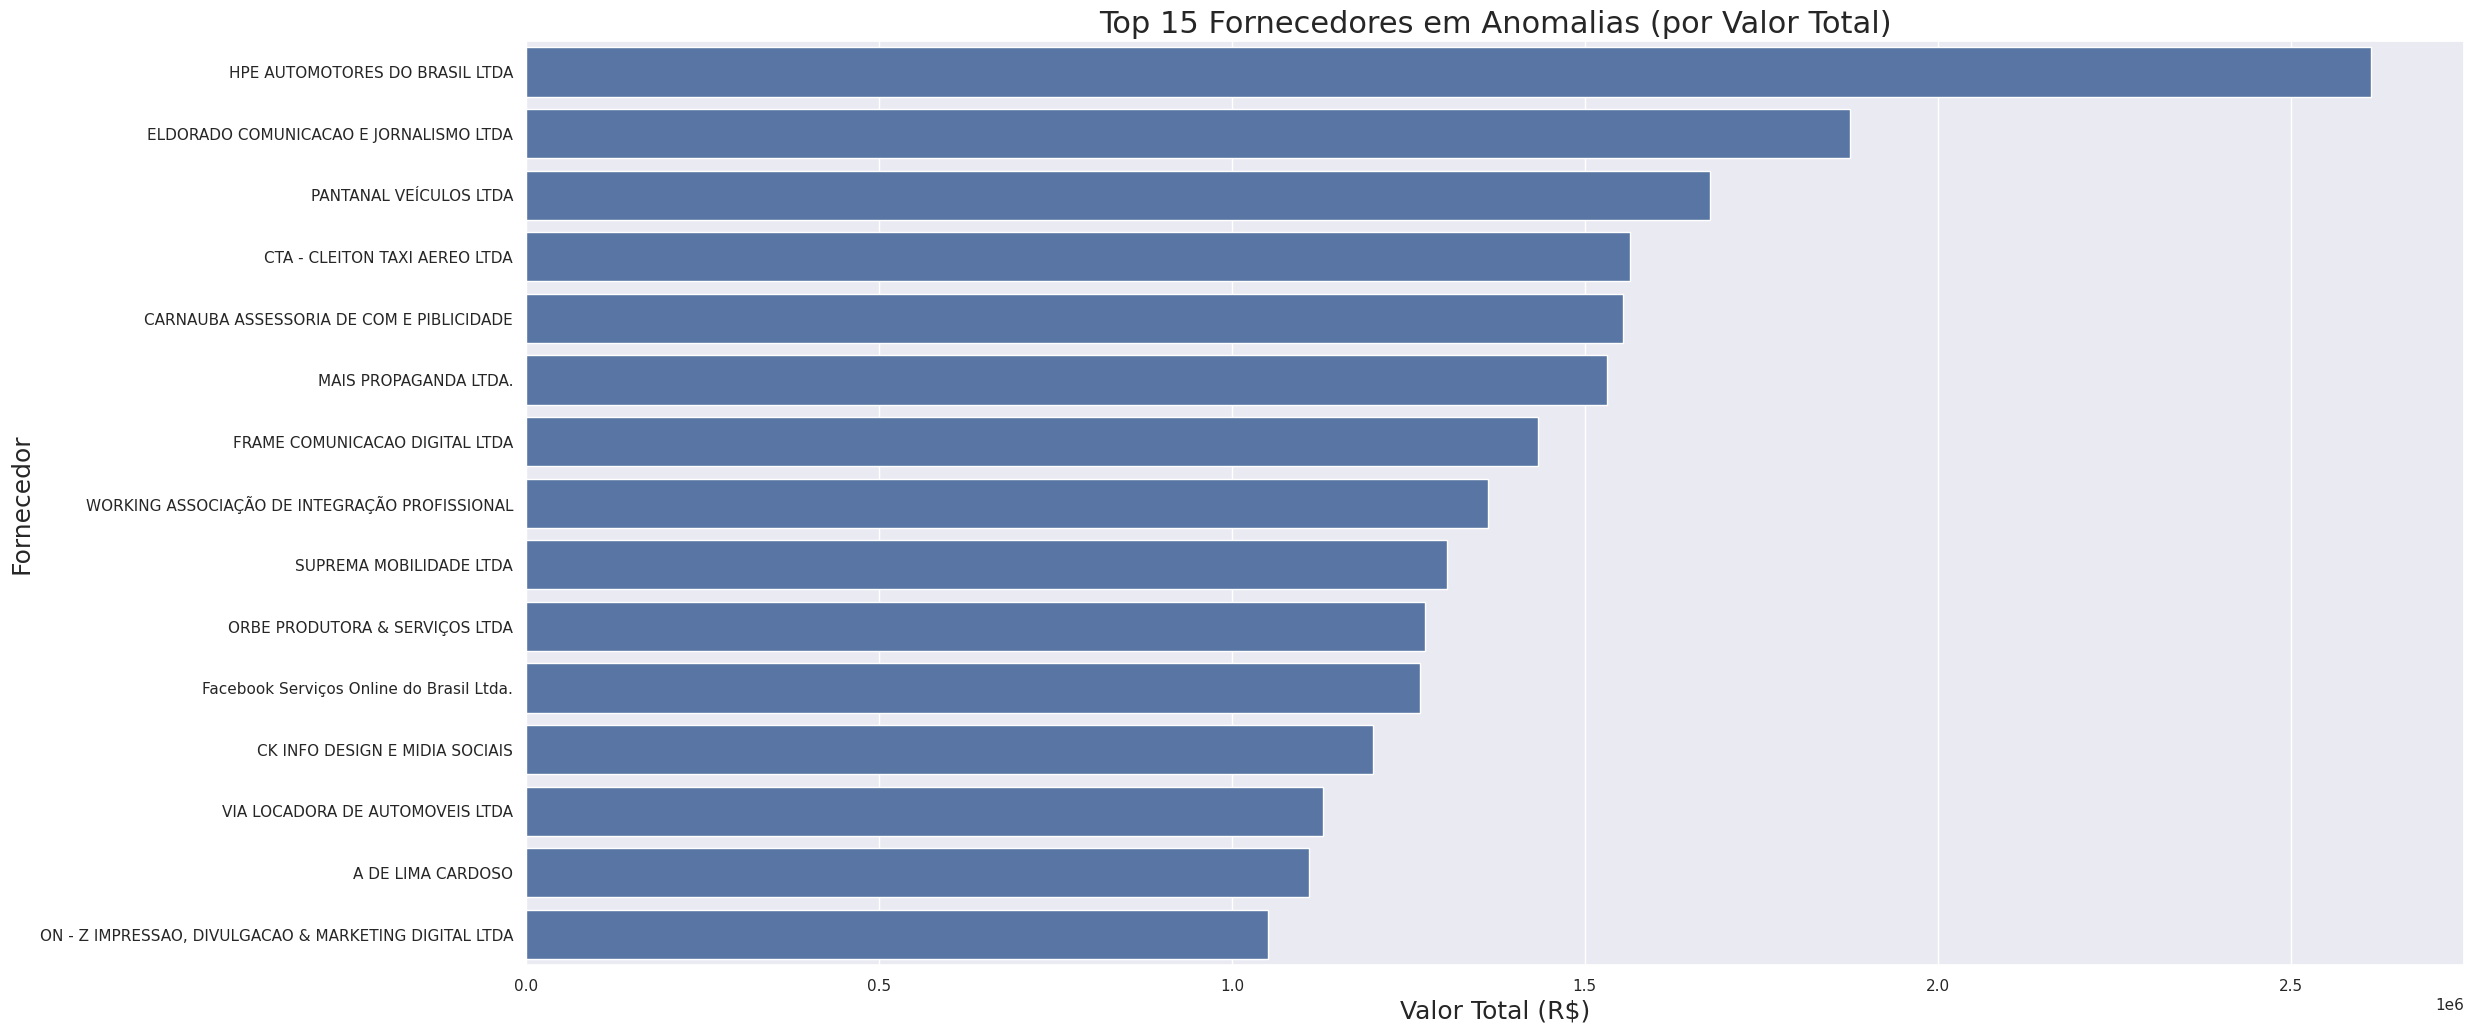

In [74]:
# top fornecedores anomalos
fornecedores = (anomalias.groupby('nome_fornecedor')
                          .agg(qtd=('valor_liquido', 'count'),
                               valor_total=('valor_liquido', 'sum'))
                          .sort_values('valor_total', ascending=False)
                          .head(15).reset_index())

sns.barplot(x='valor_total', y='nome_fornecedor', data=fornecedores)
plt.title('Top 15 Fornecedores em Anomalias (por Valor Total)', fontsize=22)
plt.xlabel('Valor Total (R$)', size=18)
plt.ylabel('Fornecedor', size=18);

# **9.2 Total Performance**

In [75]:
# resumo dos cenários por categoria
df92 = anomalias.groupby('tipo_despesa').agg(
    qtd_anomalias=('valor_liquido', 'count'),
    valor_total=('valor_liquido', 'sum'),
    valor_medio=('valor_liquido', 'mean'),
    valor_max=('valor_liquido', 'max'),
    mediana_cat=('mediana_categoria', 'mean')
).reset_index()

df92['razao_total_mediana'] = (df92['valor_medio'] / df92['mediana_cat']).round(2)
df92 = df92.sort_values('valor_total', ascending=False)
df92

,tipo_despesa,qtd_anomalias,valor_total,valor_medio,valor_max,mediana_cat,razao_total_mediana
4,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,9678,1.838796e+08,18999.749971,184428.00,3000.000,6.33
9,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,6798,5.553559e+07,8169.401328,18970.40,4950.000,1.65
10,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,5122,3.908357e+07,7630.528344,31799.40,582.850,13.09
2,COMBUSTÍVEIS E LUBRIFICANTES.,3914,1.668079e+07,4261.827971,9392.00,221.145,19.27
7,LOCAÇÃO OU FRETAMENTO DE AERONAVES,304,7.145129e+06,23503.714836,104258.00,20000.000,1.18
16,SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPE...,478,3.892369e+06,8143.031464,8700.00,510.000,15.97
19,TELEFONIA,2406,2.068428e+06,859.695869,3150.92,208.100,4.13
17,"SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO",2460,1.506681e+06,612.471927,2700.00,21.390,28.63
6,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ...",362,1.464234e+06,4044.845110,24508.80,290.000,13.95
12,PASSAGEM AÉREA - REEMBOLSO,78,1.156114e+06,14821.976154,42877.80,2328.335,6.37


In [76]:
# salvando resultados
df9.to_csv('despesas_com_anomalias.csv', index=False, encoding='utf-8-sig')
anomalias.to_csv('anomalias_detectadas.csv', index=False, encoding='utf-8-sig')

print('Arquivos salvos!')
print('   despesas_com_anomalias.csv : {} registros'.format(len(df9)))
print('   anomalias_detectadas.csv   : {} registros'.format(len(anomalias)))

Arquivos salvos!
   despesas_com_anomalias.csv : 642269 registros
   anomalias_detectadas.csv   : 32114 registros
